In [10]:
%pip install -q --upgrade pip
%pip install -q pandas numpy scikit-learn cleanlab datasets fastembed openai google-genai setfit sentence-transformers accelerate "transformers<5" tqdm


Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
guardrails-ai 0.9.3 requires click<=8.2.0, but you have click 8.3.1 which is incompatible.
guardrails-ai 0.9.3 requires typer<0.20,>=0.9.0, but you have typer 0.24.1 which is incompatible.


Note: you may need to restart the kernel to use updated packages.


#### Init

In [26]:
# Colab setup: install dependencies, mount Drive, and load secrets.

import os
from pathlib import Path

try:
    from google.colab import drive, userdata
except Exception:
    drive = None
    userdata = None

if drive is not None:
    drive.mount("/content/drive", force_remount=False)

def _secret(name: str) -> str | None:
    if userdata is not None:
        try:
            value = userdata.get(name)
            if value:
                return str(value)
        except Exception:
            pass
    value = os.getenv(name)
    return str(value) if value else None

def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start

GOOGLE_API_KEY = _secret("GOOGLE_API_KEY")
if not GOOGLE_API_KEY:
    raise ValueError("Set GOOGLE_API_KEY in Colab Secrets or environment before running the notebook.")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["GEMINI_API_KEY"] = GOOGLE_API_KEY

HF_TOKEN = _secret("HF_TOKEN")
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN

SEED = int(os.getenv("SEED", "42"))
os.environ["SEED"] = str(SEED)

if drive is not None and Path("/content/drive/MyDrive").exists():
    SAVE_ROOT = Path("/content/drive/MyDrive/data_selection_showdown")
else:
    SAVE_ROOT = _find_project_root(Path.cwd())

RESULTS_DIR = SAVE_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
os.environ["RESULTS_DIR"] = str(RESULTS_DIR)
os.environ["HF_HOME"] = str(SAVE_ROOT / ".hf")
os.environ["HF_DATASETS_CACHE"] = str(SAVE_ROOT / ".hf" / "datasets")
os.environ["TRANSFORMERS_CACHE"] = str(SAVE_ROOT / ".hf" / "transformers")

print(f"Drive mounted: {Path('/content/drive/MyDrive').exists()}")
print(f"Save root: {SAVE_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Seed: {SEED}")
print("Google API key:", "set" if GOOGLE_API_KEY else "missing")
print("HF token:", "set" if HF_TOKEN else "unset")

Drive mounted: False
Save root: d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research
Results dir: d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results
Seed: 42
Google API key: set
HF token: set


In [23]:
from __future__ import annotations

import gc
import json
import os
import re
import sys
import traceback
import warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import transformers
from datasets import Dataset as HFDataset
from datasets import Features, load_dataset
from fastembed import TextEmbedding
from IPython.display import display
from openai import OpenAI
from setfit import SetFitModel, Trainer as SetFitTrainer, TrainingArguments as SetFitArgs
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

DEFAULT_MODEL = "gemini-3.1-flash-lite-preview"
GEMMA_MODEL = DEFAULT_MODEL
GOOGLE_OPENAI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY is not set. Run the Colab setup cell and add the secret.")

client = OpenAI(
    api_key=GOOGLE_API_KEY,
    base_url=GOOGLE_OPENAI_BASE_URL,
    max_retries=30,
)

FASTEMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedder = TextEmbedding() # model_name=FASTEMBED_MODEL

# Canonical label id order from the Hugging Face PubMed-20k-RCT features.
PUBMED_LABEL_NAMES = ["background", "conclusions", "methods", "objective", "results"]
PUBMED_ID2LABEL = {idx: name for idx, name in enumerate(PUBMED_LABEL_NAMES)}
PUBMED_LABEL2ID = {name: idx for idx, name in PUBMED_ID2LABEL.items()}
# Human-readable narrative order for previews and correlated-noise sampling.
PUBMED_DISPLAY_ORDER = ["background", "objective", "methods", "results", "conclusions"]
PUBMED_CORRELATED_NEIGHBORS = {
    "background": ("objective",),
    "objective": ("background", "methods"),
    "methods": ("objective", "results"),
    "results": ("methods", "conclusions"),
    "conclusions": ("results",),
}

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

SEED = int(os.getenv("SEED", "42"))
np.random.seed(SEED)

RESULTS_DIR = Path(os.getenv("RESULTS_DIR", "/content/results"))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
os.environ["RESULTS_DIR"] = str(RESULTS_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Seed: {SEED}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Default model: {DEFAULT_MODEL}")
if HF_TOKEN:
    print("HF token: set")

ALL_RESULTS: list[dict] = []


def now_stamp() -> str:
    return datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")


def save_result(result: dict):
    """Append a result dict and save incrementally to JSON."""
    ALL_RESULTS.append(result)
    path = RESULTS_DIR / "results_incremental.json"
    path.write_text(json.dumps(ALL_RESULTS, indent=2, default=str))
    status = result.get("error", None)
    tag = "ERR" if status else "OK"
    print(f"  [{tag}] Saved {len(ALL_RESULTS)} results -> {path.name}")


def embed_texts(texts: list[str]) -> np.ndarray:
    vectors = [np.asarray(vector, dtype=np.float32) for vector in embedder.embed(texts)]
    return np.vstack(vectors) if vectors else np.zeros((0, 384), dtype=np.float32)


def label_id_from_value(value) -> int | None:
    if value is None:
        return None
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, float):
        if np.isnan(value):
            return None
        if value.is_integer():
            return int(value)
    text = str(value).strip()
    if not text:
        return None
    if text.isdigit():
        return int(text)
    lowered = text.lower()
    if lowered in PUBMED_LABEL2ID:
        return PUBMED_LABEL2ID[lowered]
    return None


def label_name_from_value(value) -> str | None:
    label_id = label_id_from_value(value)
    if label_id is not None and label_id in PUBMED_ID2LABEL:
        return PUBMED_ID2LABEL[label_id]
    if value is None:
        return None
    text = str(value).strip().lower()
    return text or None


def standardize_pubmed_frame(df: pd.DataFrame) -> pd.DataFrame:
    if "true_label" not in df.columns:
        raise KeyError(f"Expected a true_label column; got {list(df.columns)}")
    if "text" not in df.columns:
        raise KeyError(f"Expected a text column; got {list(df.columns)}")
    out = df.copy()
    out["true_label_raw"] = out["true_label"]
    out["true_label_id"] = out["true_label"].map(label_id_from_value).astype("Int64")
    out["true_label"] = out["true_label"].map(label_name_from_value)
    out["true_label_name"] = out["true_label"]
    out["text"] = out["text"].astype(str)
    out["observed_text"] = out["text"]
    out["observed_label_id"] = out["true_label_id"]
    out["observed_label_name"] = out["true_label_name"]
    out["is_corrupted"] = False
    out["corruption_kind"] = ""
    out["corruption_detail"] = ""
    return out


def load_pubmed_frame(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    df = pd.read_parquet(path)
    return standardize_pubmed_frame(df)


def discover_split_paths(dataset_dir: Path) -> dict[str, list[Path]]:
    train_paths = sorted((dataset_dir / "train_seed").glob("tier_*/samples.parquet"))
    test_paths = sorted((dataset_dir / "test").glob("tier_*/samples.parquet"))
    return {"train": train_paths, "test": test_paths}


def select_split_path(paths: list[Path], tier: int) -> Path:
    tier_name = f"tier_{int(tier)}"
    for path in paths:
        if path.parent.name == tier_name:
            return path
    available = ", ".join(path.as_posix() for path in paths) or "<none>"
    raise FileNotFoundError(f"Could not find {tier_name} in: {available}")


def preview_rows(
    df: pd.DataFrame,
    *,
    n: int = 5,
    columns: list[str] | None = None,
    random_state: int = SEED,
) -> pd.DataFrame:
    if df.empty:
        print("No rows to preview.")
        return df.head(0)
    sample = df.head(n) if n >= len(df) else df.sample(n=n, random_state=random_state)
    default_columns = [
        "sample_id",
        "true_label",
        "observed_label_name",
        "is_corrupted",
        "corruption_kind",
        "observed_text",
    ]
    chosen_columns = columns or default_columns
    visible_columns = [column for column in chosen_columns if column in sample.columns]
    preview = sample.loc[:, visible_columns].copy()
    text_columns = [column for column in ("observed_text", "text") if column in preview.columns]
    for column in text_columns:
        preview[column] = preview[column].astype(str).str.slice(0, 220)
    display(preview.reset_index(drop=True))
    return sample


def preview_label_examples(
    df: pd.DataFrame,
    label_name: str,
    *,
    n: int = 5,
    label_col: str = "true_label",
) -> pd.DataFrame:
    subset = df.loc[df[label_col].astype(str) == str(label_name)]
    return preview_rows(subset, n=n)


def show_corrupted_rows(df: pd.DataFrame, *, n: int = 5) -> pd.DataFrame:
    subset = df.loc[df["is_corrupted"].astype(bool)]
    return preview_rows(subset, n=n)


def print_label_counts(df: pd.DataFrame, *, label_col: str = "true_label") -> pd.Series:
    counts = df[label_col].astype(str).value_counts()
    ordered = [label for label in PUBMED_DISPLAY_ORDER if label in counts.index]
    remaining = [label for label in counts.index if label not in ordered]
    counts = counts.reindex(ordered + remaining).dropna().astype(int)
    print(counts.to_string())
    return counts


def print_most_confused_labels(
    df: pd.DataFrame,
    *,
    true_col: str = "true_label",
    pred_col: str = "observed_label_name",
    top_k: int = 10,
) -> pd.DataFrame:
    needed = {true_col, pred_col}
    missing = [column for column in needed if column not in df.columns]
    if missing:
        raise KeyError(f"Missing columns for confusion summary: {missing}")
    confused = (
        df.loc[df[true_col].astype(str) != df[pred_col].astype(str), [true_col, pred_col]]
        .astype(str)
        .value_counts()
        .rename("count")
        .reset_index()
        .sort_values(["count", true_col, pred_col], ascending=[False, True, True])
        .head(top_k)
    )
    if confused.empty:
        print("No confusions found.")
    else:
        print(confused.to_string(index=False))
    return confused


def summarize_corruption(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.assign(corruption_kind=df["corruption_kind"].replace("", "clean"))
        .groupby(["true_label", "corruption_kind"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values(["true_label", "corruption_kind"], ascending=[True, True])
    )
    print(summary.to_string(index=False))
    return summary


Device: cpu
Seed: 42
Results dir: d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results
Default model: gemini-3.1-flash-lite-preview
HF token: set


In [12]:
import pickle

SAMPLES_CLEANING_CACHE_DIR = RESULTS_DIR / "samples_cleaning"
SAMPLES_CLEANING_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def cache_file(name: str) -> Path:
    return SAMPLES_CLEANING_CACHE_DIR / name


def load_cache(path: Path) -> Any:
    with path.open("rb") as handle:
        return pickle.load(handle)


def save_cache(path: Path, value: Any) -> None:
    if path.exists():
        raise FileExistsError(f"Cache file already exists: {path}")
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("xb") as handle:
        pickle.dump(value, handle, protocol=pickle.HIGHEST_PROTOCOL)


def load_or_compute_cache(path: Path, builder):
    if path.exists():
        return load_cache(path)
    value = builder()
    save_cache(path, value)
    return value

In [21]:
# Load all cached artifacts from previous experiment runs
artifacts_loaded = {}

artifact_names = [
    "train_eval_df.pkl",
    "committee_standard.pkl",
    "cleanlab_standard.pkl",
    "confidence_x3.pkl",
    "dinco_two_pass.pkl",
    "self_moe_two_pass.pkl",
    "confidence_overlap.pkl",
    "cleanlab_experiment_suite.pkl",
    "experiment_summary.pkl",
]

for artifact_name in artifact_names:
    artifact_path = cache_file(artifact_name)
    if artifact_path.exists():
        try:
            artifacts_loaded[artifact_name] = load_cache(artifact_path)
            print(f"Loaded {artifact_name}")
        except Exception as e:
            print(f"Error loading {artifact_name}: {e}")
    else:
        print(f"Missing {artifact_name}")

# Unpack key artifacts for use in downstream analysis
train_eval_df = artifacts_loaded.get("train_eval_df.pkl", train_eval_df)
committee_standard = artifacts_loaded.get("committee_standard.pkl")
cleanlab_standard_bundle = artifacts_loaded.get("cleanlab_standard.pkl")
confidence_x3 = artifacts_loaded.get("confidence_x3.pkl")
dinco = artifacts_loaded.get("dinco_two_pass.pkl")
self_moe = artifacts_loaded.get("self_moe_two_pass.pkl")
confidence_overlap_bundle = artifacts_loaded.get("confidence_overlap.pkl")
cleanlab_experiment_suite = artifacts_loaded.get("cleanlab_experiment_suite.pkl")
experiment_summary = artifacts_loaded.get("experiment_summary.pkl")

print(f"\nSuccessfully loaded {len(artifacts_loaded)} artifacts")

Loaded train_eval_df.pkl
Error loading committee_standard.pkl: Can't get attribute 'MemberSpec' on <module '__main__'>
Loaded cleanlab_standard.pkl
Loaded confidence_x3.pkl
Loaded dinco_two_pass.pkl
Loaded self_moe_two_pass.pkl
Loaded confidence_overlap.pkl
Loaded cleanlab_experiment_suite.pkl
Loaded experiment_summary.pkl

Successfully loaded 8 artifacts


In [22]:
experiment_summary

,method,accuracy,f1_macro,agreement_rate,stage_change_rate,decision_confidence_mean,confident_but_wrong_rate,flagged_rows,precision,recall,f1
0,committee_standard,0.84,0.762969,0.92,NaN,0.973333,0.16,NaN,NaN,NaN,NaN
1,cleanlab_standard,NaN,NaN,NaN,NaN,NaN,NaN,17.0,0.941176,0.615385,0.744186
2,confidence_x3,0.82,0.739304,0.92,NaN,0.961133,0.18,NaN,NaN,NaN,NaN
3,dinco_two_pass,0.86,0.780519,NaN,0.02,0.976000,0.14,NaN,NaN,NaN,NaN
4,self_moe_two_pass,0.84,0.763824,NaN,0.00,0.957200,0.16,NaN,NaN,NaN,NaN


In [13]:
DATASET_NAME = "pubmed_20k_rct"


def resolve_dataset_dir(dataset_name: str) -> Path:
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents]
    for root in search_roots:
        candidate = root / "data" / "processed" / dataset_name
        if candidate.exists():
            return candidate
    fallback = Path("../data/processed") / dataset_name
    if fallback.exists():
        return fallback
    raise FileNotFoundError(
        f"Could not find data/processed/{dataset_name} from {cwd}."
    )


DATASET_DIR = resolve_dataset_dir(DATASET_NAME)
print(f"Resolved dataset dir: {DATASET_DIR}")

split_candidates = discover_split_paths(DATASET_DIR)
print("Available train splits:")
for path in split_candidates["train"]:
    print("  ", path.as_posix())
print("Available test splits:")
for path in split_candidates["test"]:
    print("  ", path.as_posix())

TRAIN_PATH = select_split_path(split_candidates["train"], tier=100)
TEST_PATH = select_split_path(split_candidates["test"], tier=200)
print(f"Selected train split: {TRAIN_PATH.as_posix()}")
print(f"Selected test split: {TEST_PATH.as_posix()}")

train_df = load_pubmed_frame(TRAIN_PATH)
test_df = load_pubmed_frame(TEST_PATH)

print(f"Train rows: {len(train_df):,}")
print_label_counts(train_df)
print(f"Test rows: {len(test_df):,}")
print_label_counts(test_df)

print("\nTrain preview")
preview_rows(train_df, n=5)
print("\nTest preview")
preview_rows(test_df, n=5)

FRAC_CORRUPTED_PER_GROUP = float(os.getenv("FRAC_CORRUPTED_PER_GROUP", "0.17"))
TEXT_CORRUPTION_MODE = os.getenv("TEXT_CORRUPTION_MODE", "word_dropout")
print(f"Corruption fraction per group: {FRAC_CORRUPTED_PER_GROUP:.3f}")
print(f"Text corruption mode: {TEXT_CORRUPTION_MODE}")


Resolved dataset dir: D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\data\processed\pubmed_20k_rct
Available train splits:
   D:/Coding/VSCFiles/IndependentProjects/AI/uni-judge-research/data/processed/pubmed_20k_rct/train_seed/tier_10/samples.parquet
   D:/Coding/VSCFiles/IndependentProjects/AI/uni-judge-research/data/processed/pubmed_20k_rct/train_seed/tier_100/samples.parquet
   D:/Coding/VSCFiles/IndependentProjects/AI/uni-judge-research/data/processed/pubmed_20k_rct/train_seed/tier_5000/samples.parquet
Available test splits:
   D:/Coding/VSCFiles/IndependentProjects/AI/uni-judge-research/data/processed/pubmed_20k_rct/test/tier_20/samples.parquet
   D:/Coding/VSCFiles/IndependentProjects/AI/uni-judge-research/data/processed/pubmed_20k_rct/test/tier_200/samples.parquet
   D:/Coding/VSCFiles/IndependentProjects/AI/uni-judge-research/data/processed/pubmed_20k_rct/test/tier_5000/samples.parquet
Selected train split: D:/Coding/VSCFiles/IndependentProjects/AI/uni-judge-rese

,sample_id,true_label,observed_label_name,is_corrupted,corruption_kind,observed_text
0,train_73717,methods,methods,False,,"We conducted a prospective , randomized trial to compare the efficacy and safety of two protocols of iv @ g methylprednisolone in a tota..."
1,train_2423,results,results,False,,Interactions between time of measurement and group were significant for theory of mind and social engagement .
2,train_59694,results,results,False,,Levels of @F@ and @E@ declined exponentially thereafter with similar estimated half-lives ( @ and @ hours ) .
3,train_169195,methods,methods,False,,"We did a multicentre , double-dummy , randomised , placebo controlled trial across @ primary care centres in Sydney , Australia , from N..."
4,train_167569,conclusions,conclusions,False,,Caffeine does not appear to provide an alternative for patients unable to tolerate the water drinking test .



Test preview


,sample_id,true_label,observed_label_name,is_corrupted,corruption_kind,observed_text
0,test_22463,methods,methods,False,,Symptomatic severity and functional status were measured using Boston Carpal Tunnel Questionnaire .
1,test_11678,background,background,False,,"Despite being a critical survivorship care issue , there is a clear gap in current knowledge of the optimal treatment of sexual dysfunct..."
2,test_13953,objective,objective,False,,We evaluated the effectiveness of electronically delivered decision support tools at reducing antibiotic prescribing for respiratory tra...
3,test_3671,methods,methods,False,,"In the Group C , Zhangmo decoction was jointly used on the @th day of menstrual cycle ."
4,test_26505,results,results,False,,"With the linagliptin @ mg/metformin @ mg dose , the adjusted geometric mean ratio of the SPC to the separate tablets for linagliptin was..."


Corruption fraction per group: 0.170
Text corruption mode: word_dropout


In [14]:
def _available_pubmed_labels(df: pd.DataFrame) -> list[str]:
    label_set = set(df["true_label"].astype(str).tolist())
    ordered = [label for label in PUBMED_DISPLAY_ORDER if label in label_set]
    return ordered or sorted(label_set)


def _sample_group_indices(indexes: np.ndarray, n_corrupt: int, rng: np.random.Generator) -> np.ndarray:
    n_corrupt = int(min(max(n_corrupt, 0), len(indexes)))
    if n_corrupt == 0:
        return np.array([], dtype=indexes.dtype)
    return rng.choice(indexes, size=n_corrupt, replace=False)


def corrupt_labels_random(
    df: pd.DataFrame,
    *,
    frac_corrupted_per_group: float = 0.1,
    seed: int = SEED,
) -> pd.DataFrame:
    out = df.copy()
    rng = np.random.default_rng(seed)
    group_names = _available_pubmed_labels(out)
    true_labels = out["true_label"].astype(str)
    for group_name in group_names:
        group_idx = out.index[true_labels == group_name].to_numpy()
        if float(frac_corrupted_per_group) <= 0:
            continue
        n_corrupt = max(1, int(round(len(group_idx) * float(frac_corrupted_per_group))))
        chosen_idx = _sample_group_indices(group_idx, n_corrupt, rng)
        for row_idx in chosen_idx:
            choices = [label for label in group_names if label != str(out.at[row_idx, "true_label"])]
            if not choices:
                continue
            new_label = str(rng.choice(choices))
            out.at[row_idx, "observed_label_name"] = new_label
            out.at[row_idx, "observed_label_id"] = PUBMED_LABEL2ID[new_label]
            out.at[row_idx, "is_corrupted"] = True
            out.at[row_idx, "corruption_kind"] = "random_label"
            out.at[row_idx, "corruption_detail"] = f"{out.at[row_idx, 'true_label']}->{new_label}"
    return out


def corrupt_labels_correlated(
    df: pd.DataFrame,
    *,
    frac_corrupted_per_group: float = 0.1,
    seed: int = SEED,
) -> pd.DataFrame:
    out = df.copy()
    rng = np.random.default_rng(seed)
    group_names = _available_pubmed_labels(out)
    true_labels = out["true_label"].astype(str)
    for group_name in group_names:
        group_idx = out.index[true_labels == group_name].to_numpy()
        if float(frac_corrupted_per_group) <= 0:
            continue
        n_corrupt = max(1, int(round(len(group_idx) * float(frac_corrupted_per_group))))
        chosen_idx = _sample_group_indices(group_idx, n_corrupt, rng)
        choices = [label for label in PUBMED_CORRELATED_NEIGHBORS.get(group_name, ()) if label in group_names]
        if not choices:
            continue
        for row_idx in chosen_idx:
            new_label = str(rng.choice(choices))
            out.at[row_idx, "observed_label_name"] = new_label
            out.at[row_idx, "observed_label_id"] = PUBMED_LABEL2ID[new_label]
            out.at[row_idx, "is_corrupted"] = True
            out.at[row_idx, "corruption_kind"] = "correlated_label"
            out.at[row_idx, "corruption_detail"] = f"{out.at[row_idx, 'true_label']}->{new_label}"
    return out


def _corrupt_text(text: str, rng: np.random.Generator, mode: str) -> str:
    words = str(text).split()
    if len(words) <= 3:
        return " ".join(words[: max(1, len(words) - 1)]) if words else text
    if mode == "word_dropout":
        keep_mask = rng.random(len(words)) >= 0.25
        if keep_mask.sum() < 2:
            keep_mask[rng.choice(len(words), size=min(2, len(words)), replace=False)] = True
        return " ".join([word for word, keep in zip(words, keep_mask) if keep])
    if mode == "word_shuffle":
        shuffled = words.copy()
        rng.shuffle(shuffled)
        return " ".join(shuffled)
    if mode == "truncate":
        cutoff = int(rng.integers(max(2, len(words) // 2), len(words)))
        return " ".join(words[:cutoff])
    if mode == "swap_adjacent":
        shuffled = words.copy()
        for index in range(0, len(shuffled) - 1, 2):
            if rng.random() < 0.5:
                shuffled[index], shuffled[index + 1] = shuffled[index + 1], shuffled[index]
        return " ".join(shuffled)
    raise ValueError(f"Unknown text corruption mode: {mode}")


def corrupt_texts(
    df: pd.DataFrame,
    *,
    frac_corrupted_per_group: float = 0.1,
    seed: int = SEED,
    mode: str = "word_dropout",
) -> pd.DataFrame:
    out = df.copy()
    rng = np.random.default_rng(seed)
    group_names = _available_pubmed_labels(out)
    true_labels = out["true_label"].astype(str)
    for group_name in group_names:
        group_idx = out.index[true_labels == group_name].to_numpy()
        if float(frac_corrupted_per_group) <= 0:
            continue
        n_corrupt = max(1, int(round(len(group_idx) * float(frac_corrupted_per_group))))
        chosen_idx = _sample_group_indices(group_idx, n_corrupt, rng)
        for row_idx in chosen_idx:
            original_text = str(out.at[row_idx, "text"])
            corrupted_text = _corrupt_text(original_text, rng, mode)
            out.at[row_idx, "observed_text"] = corrupted_text
            out.at[row_idx, "is_corrupted"] = True
            out.at[row_idx, "corruption_kind"] = f"text_{mode}"
            out.at[row_idx, "corruption_detail"] = mode
    return out


def build_experiment_variant(
    df: pd.DataFrame,
    *,
    corruption_kind: str,
    frac_corrupted_per_group: float = 0.1,
    seed: int = SEED,
    text_mode: str = "word_dropout",
) -> pd.DataFrame:
    corruption_kind = corruption_kind.lower().strip()
    if corruption_kind in {"random_label", "label_noise", "random"}:
        return corrupt_labels_random(df, frac_corrupted_per_group=frac_corrupted_per_group, seed=seed)
    if corruption_kind in {"correlated_label", "correlated", "label_noise_correlated"}:
        return corrupt_labels_correlated(df, frac_corrupted_per_group=frac_corrupted_per_group, seed=seed)
    if corruption_kind in {"text", "text_noise", "corrupted_text"}:
        return corrupt_texts(df, frac_corrupted_per_group=frac_corrupted_per_group, seed=seed, mode=text_mode)
    raise ValueError(f"Unknown corruption_kind: {corruption_kind}")


print(f"Corruption fraction per group: {FRAC_CORRUPTED_PER_GROUP:.3f}")
print(f"Text corruption mode: {TEXT_CORRUPTION_MODE}")

train_random_label_noise = corrupt_labels_random(
    train_df,
    frac_corrupted_per_group=FRAC_CORRUPTED_PER_GROUP,
    seed=SEED,
)
train_correlated_label_noise = corrupt_labels_correlated(
    train_df,
    frac_corrupted_per_group=FRAC_CORRUPTED_PER_GROUP,
    seed=SEED,
)
train_text_noise = corrupt_texts(
    train_df,
    frac_corrupted_per_group=FRAC_CORRUPTED_PER_GROUP,
    seed=SEED,
    mode=TEXT_CORRUPTION_MODE,
)

print("\nRandom label noise summary")
summarize_corruption(train_random_label_noise)
print("\nMost confusing labels under random label noise")
print_most_confused_labels(
    train_random_label_noise,
    true_col="true_label",
    pred_col="observed_label_name",
    top_k=10,
)
print("\nRandom label noise preview")
show_corrupted_rows(train_random_label_noise, n=5)

print("\nCorrelated label noise summary")
summarize_corruption(train_correlated_label_noise)
print("\nMost confusing labels under correlated label noise")
print_most_confused_labels(
    train_correlated_label_noise,
    true_col="true_label",
    pred_col="observed_label_name",
    top_k=10,
)
print("\nCorrelated label noise preview")
show_corrupted_rows(train_correlated_label_noise, n=5)

print("\nText corruption summary")
summarize_corruption(train_text_noise)
print("\nCorrupted text preview")
preview_rows(
    train_text_noise.loc[train_text_noise["is_corrupted"].astype(bool)],
    n=5,
    columns=[
        "sample_id",
        "true_label",
        "observed_label_name",
        "corruption_kind",
        "text",
        "observed_text",
    ],
)


Corruption fraction per group: 0.170
Text corruption mode: word_dropout

Random label noise summary
 true_label corruption_kind  count
 background           clean      8
 background    random_label      2
conclusions           clean     12
conclusions    random_label      3
    methods           clean     28
    methods    random_label      6
  objective           clean      7
  objective    random_label      1
    results           clean     27
    results    random_label      6

Most confusing labels under random label noise
 true_label observed_label_name  count
 background             methods      2
    methods         conclusions      2
    methods           objective      2
    results          background      2
    results         conclusions      2
conclusions             methods      1
conclusions           objective      1
conclusions             results      1
    methods          background      1
    methods             results      1

Random label noise preview


,sample_id,true_label,observed_label_name,is_corrupted,corruption_kind,observed_text
0,train_105918,methods,conclusions,True,random_label,"Fifty-seven adolescents , between @ and @ years old , were allocated to individual cognitive therapy , CBTG or AP ."
1,train_11204,background,methods,True,random_label,"A candidate tetravalent dengue vaccine is being assessed in three clinical trials involving more than @,@ children between the ages of @..."
2,train_28745,results,conclusions,True,random_label,"For AS impressions , multivariate analysis of variance revealed a significant influence of the individual tooth and the degree to which ..."
3,train_164771,results,background,True,random_label,"The incidence of bronchopulmonary dysplasia was @ % in the budesonide group versus @ % in the placebo group ( relative risk , stratified..."
4,train_144147,conclusions,objective,True,random_label,The CDSS is demonstrated to be effective in identifying the earliest time of ventilator weaning for patients to resume and sustain spont...



Correlated label noise summary
 true_label  corruption_kind  count
 background            clean      8
 background correlated_label      2
conclusions            clean     12
conclusions correlated_label      3
    methods            clean     28
    methods correlated_label      6
  objective            clean      7
  objective correlated_label      1
    results            clean     27
    results correlated_label      6

Most confusing labels under correlated label noise
 true_label observed_label_name  count
    results         conclusions      4
conclusions             results      3
    methods           objective      3
    methods             results      3
 background           objective      2
    results             methods      2
  objective          background      1

Correlated label noise preview


,sample_id,true_label,observed_label_name,is_corrupted,corruption_kind,observed_text
0,train_105918,methods,objective,True,correlated_label,"Fifty-seven adolescents , between @ and @ years old , were allocated to individual cognitive therapy , CBTG or AP ."
1,train_11204,background,objective,True,correlated_label,"A candidate tetravalent dengue vaccine is being assessed in three clinical trials involving more than @,@ children between the ages of @..."
2,train_21569,methods,objective,True,correlated_label,"In NAVIGATOR , patients with impaired glucose tolerance were randomly allocated to receive valsartan or placebo and nateglinide or place..."
3,train_123211,methods,results,True,correlated_label,Secondary outcomes included new MDRO acquisitions and new clinically defined device-associated infections .
4,train_117870,conclusions,results,True,correlated_label,MBHD favorably improved early recovery of neural functions of CSCS patients ( @ months after surgery ) .



Text corruption summary
 true_label   corruption_kind  count
 background             clean      8
 background text_word_dropout      2
conclusions             clean     12
conclusions text_word_dropout      3
    methods             clean     28
    methods text_word_dropout      6
  objective             clean      7
  objective text_word_dropout      1
    results             clean     27
    results text_word_dropout      6

Corrupted text preview


,sample_id,true_label,observed_label_name,corruption_kind,text,observed_text
0,train_105423,methods,methods,text_word_dropout,All received routine treatment .,All received routine treatment .
1,train_11204,background,background,text_word_dropout,"A candidate tetravalent dengue vaccine is being assessed in three clinical trials involving more than @,@ children between the ages of @...",A candidate dengue vaccine is assessed in three clinical trials involving than children between the ages of @ and years and Latin Americ...
2,train_167569,conclusions,conclusions,text_word_dropout,Caffeine does not appear to provide an alternative for patients unable to tolerate the water drinking test .,Caffeine not appear provide an alternative for patients unable to tolerate water drinking test .
3,train_131856,methods,methods,text_word_dropout,The primary focus was on parent-child communication and parenting .,focus was on parent-child communication and parenting .
4,train_120676,methods,methods,text_word_dropout,"We estimated a sample size of @ physicians in each group , corresponding to @ clusters with a mean size of @ physicians .","We estimated a sample size of @ physicians in group , to clusters with a mean size @"


,sample_id,dataset_name,text,true_label,meta_json,true_label_raw,true_label_id,true_label_name,observed_text,observed_label_id,observed_label_name,is_corrupted,corruption_kind,corruption_detail
3,train_105423,pubmed_20k_rct,All received routine treatment .,methods,"{""hf_dataset"": ""pietrolesci/pubmed-20k-rct"", ""hf_config"": null, ""orig_split"": ""train"", ""orig_row"": 105423, ""label_col"": ""labels""}",2,2,methods,All received routine treatment .,2,methods,True,text_word_dropout,word_dropout
7,train_11204,pubmed_20k_rct,"A candidate tetravalent dengue vaccine is being assessed in three clinical trials involving more than @,@ children between the ages of @...",background,"{""hf_dataset"": ""pietrolesci/pubmed-20k-rct"", ""hf_config"": null, ""orig_split"": ""train"", ""orig_row"": 11204, ""label_col"": ""labels""}",0,0,background,A candidate dengue vaccine is assessed in three clinical trials involving than children between the ages of @ and years and Latin Americ...,0,background,True,text_word_dropout,word_dropout
44,train_167569,pubmed_20k_rct,Caffeine does not appear to provide an alternative for patients unable to tolerate the water drinking test .,conclusions,"{""hf_dataset"": ""pietrolesci/pubmed-20k-rct"", ""hf_config"": null, ""orig_split"": ""train"", ""orig_row"": 167569, ""label_col"": ""labels""}",1,1,conclusions,Caffeine not appear provide an alternative for patients unable to tolerate water drinking test .,1,conclusions,True,text_word_dropout,word_dropout
21,train_131856,pubmed_20k_rct,The primary focus was on parent-child communication and parenting .,methods,"{""hf_dataset"": ""pietrolesci/pubmed-20k-rct"", ""hf_config"": null, ""orig_split"": ""train"", ""orig_row"": 131856, ""label_col"": ""labels""}",2,2,methods,focus was on parent-child communication and parenting .,2,methods,True,text_word_dropout,word_dropout
14,train_120676,pubmed_20k_rct,"We estimated a sample size of @ physicians in each group , corresponding to @ clusters with a mean size of @ physicians .",methods,"{""hf_dataset"": ""pietrolesci/pubmed-20k-rct"", ""hf_config"": null, ""orig_split"": ""train"", ""orig_row"": 120676, ""label_col"": ""labels""}",2,2,methods,"We estimated a sample size of @ physicians in group , to clusters with a mean size @",2,methods,True,text_word_dropout,word_dropout


# EXPERIMENTS

In [29]:
import re
from collections import Counter
from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd
from cleanlab.filter import find_label_issues
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score

from src.datasets.splitter import stratified_take
from src.models.ensemble import CommitteeMember, CommitteePredictor
from src.models.llm import GoogleGenaiBatchParams, GoogleGenaiBatchPredictor

EVAL_SAMPLE_N = 50
CORRUPTION_GROUP_SHARE = 0.17
STANDARD_TEMPERATURE = 0.0
SELF_MOE_TEMPERATURE = 2.0
BATCH_SIZE = 4
MAX_CONCURRENCY = 2
MAX_TOKENS = 512
MAX_RETRIES = 5
PROMPT_ID = "baseline_v1"
ALLOWED_LABELS = list(PUBMED_LABEL_NAMES)
LABEL_TO_IDX = {label: idx for idx, label in enumerate(ALLOWED_LABELS)}


@dataclass(frozen=True)
class MemberSpec:
    name: str
    model_id: str
    temperature: float


def safe_name(value: str) -> str:
    return re.sub(r"[^a-zA-Z0-9]+", "_", value).strip("_").lower()


def build_member_predictor(spec: MemberSpec) -> GoogleGenaiBatchPredictor:
    params = GoogleGenaiBatchParams(
        model_id=spec.model_id,
        prompt_id=PROMPT_ID,
        few_shot=[],
        batch_size=BATCH_SIZE,
        max_concurrency=MAX_CONCURRENCY,
        temperature=spec.temperature,
        max_tokens=MAX_TOKENS,
        retries=MAX_RETRIES,
        thinking_level="off",
        include_thoughts=False,
    )
    return GoogleGenaiBatchPredictor(params=params, name=f"member:{spec.name}")


def build_committee(member_specs: list[MemberSpec], committee_name: str) -> CommitteePredictor:
    members = [CommitteeMember(name=spec.name, predictor=build_member_predictor(spec)) for spec in member_specs]
    return CommitteePredictor(members, name=committee_name)


def member_label_map(pred: Any) -> dict[str, str | None]:
    raw = pred.raw if isinstance(pred.raw, dict) else {}
    committee_raw = raw.get("committee", {}) if isinstance(raw, dict) else {}
    members = committee_raw.get("members", []) if isinstance(committee_raw, dict) else []
    labels: dict[str, str | None] = {}
    for item in members:
        name = str(item.get("name"))
        label = item.get("pred_label")
        labels[name] = None if label is None else str(label)
    return labels


def member_labels_to_probs(member_label_rows: list[dict[str, str | None]]) -> np.ndarray:
    probs = np.zeros((len(member_label_rows), len(ALLOWED_LABELS)), dtype=float)
    for row_idx, member_labels in enumerate(member_label_rows):
        valid = [label for label in member_labels.values() if label in LABEL_TO_IDX]
        if not valid:
            probs[row_idx, :] = 1.0 / len(ALLOWED_LABELS)
            continue
        counts = Counter(valid)
        total = float(len(valid))
        for label, count in counts.items():
            probs[row_idx, LABEL_TO_IDX[label]] = float(count) / total
    return probs


def _take_disjoint_stratified_subset(df: pd.DataFrame, n_rows: int, *, seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    n_rows = int(min(max(n_rows, 0), len(df)))
    if n_rows == 0:
        return df.head(0).copy(), df.copy()
    chosen = stratified_take(df, n_rows, label_col="true_label", seed=seed).reset_index(drop=True)
    chosen_ids = set(chosen["sample_id"].astype(str).tolist())
    remaining = df.loc[~df["sample_id"].astype(str).isin(chosen_ids)].reset_index(drop=True)
    return chosen, remaining


def _fully_corrupt_subset(df: pd.DataFrame, kind: str, *, seed: int) -> pd.DataFrame:
    kind = kind.strip().lower()
    if kind == "random_label":
        return corrupt_labels_random(df, frac_corrupted_per_group=1.0, seed=seed)
    if kind == "correlated_label":
        return corrupt_labels_correlated(df, frac_corrupted_per_group=1.0, seed=seed)
    if kind.startswith("text_"):
        mode = kind.split("text_", 1)[1]
        return corrupt_texts(df, frac_corrupted_per_group=1.0, seed=seed, mode=mode)
    raise ValueError(f"Unknown corruption kind: {kind}")


def build_corruption_eval_frame(
    source_df: pd.DataFrame,
    *,
    eval_sample_n: int = EVAL_SAMPLE_N,
    corruption_share: float = CORRUPTION_GROUP_SHARE,
    seed: int = SEED,
) -> pd.DataFrame:
    base = stratified_take(source_df, eval_sample_n, label_col="true_label", seed=seed).reset_index(drop=True)
    corruption_kinds = ["random_label", "correlated_label", f"text_{TEXT_CORRUPTION_MODE}"]
    target_corrupted = int(round(len(base) * corruption_share * len(corruption_kinds)))
    group_sizes = [target_corrupted // len(corruption_kinds)] * len(corruption_kinds)
    for index in range(target_corrupted % len(corruption_kinds)):
        group_sizes[index] += 1

    remaining = base.copy()
    pieces: list[pd.DataFrame] = []
    for index, (kind, group_size) in enumerate(zip(corruption_kinds, group_sizes)):
        subset, remaining = _take_disjoint_stratified_subset(remaining, group_size, seed=seed + index)
        corrupted = _fully_corrupt_subset(subset, kind, seed=seed + index)
        corrupted = corrupted.copy()
        corrupted["kind"] = kind
        pieces.append(corrupted)

    clean = remaining.copy()
    clean["kind"] = "clean"
    clean["corruption_kind"] = "clean"
    clean["corruption_detail"] = ""
    clean["is_corrupted"] = False
    clean["observed_label_name"] = clean["true_label_name"]
    clean["observed_label_id"] = clean["true_label_id"]
    pieces.append(clean)

    out = pd.concat(pieces, ignore_index=True)
    out["kind"] = pd.Categorical(out["kind"].astype(str), categories=["clean", *corruption_kinds], ordered=True)
    out["row"] = np.arange(len(out), dtype=int)
    return out.sort_values("row").reset_index(drop=True)


def build_result_table(
    df: pd.DataFrame,
    preds: list[Any],
    member_specs: list[MemberSpec],
) -> tuple[pd.DataFrame, np.ndarray]:
    member_label_rows = [member_label_map(pred) for pred in preds]
    probs = member_labels_to_probs(member_label_rows)
    pred_cols = [f"pred_{safe_name(spec.name)}" for spec in member_specs]
    records: list[dict[str, Any]] = []
    for row_idx, (row, pred, member_labels) in enumerate(zip(df.itertuples(index=False), preds, member_label_rows)):
        vote_counts = Counter(label for label in member_labels.values() if label in LABEL_TO_IDX)
        vote_total = sum(vote_counts.values())
        majority_vote = None if pred.pred_label is None else str(pred.pred_label)
        majority_correct = majority_vote == str(getattr(row, "true_label"))
        majority_vote_share = float(max(vote_counts.values()) / vote_total) if vote_total else 0.0
        kind_value = getattr(row, "kind", "clean")
        kind_value = "clean" if kind_value is None or str(kind_value).strip() == "" else str(kind_value)
        record: dict[str, Any] = {
            "row": row_idx,
            "kind": kind_value,
            "sample_id": str(getattr(row, "sample_id")),
            "true_label": str(getattr(row, "true_label")),
            "is_corrupted": bool(getattr(row, "is_corrupted", False)),
            "majority_vote": majority_vote,
            "ensemble_pred": majority_vote,
            "majority_correct": bool(majority_correct),
            "majority_vote_share": majority_vote_share,
            "confident_but_wrong": bool(majority_vote_share >= (2 / 3) and not majority_correct),
        }
        for spec, column_name in zip(member_specs, pred_cols):
            record[column_name] = member_labels.get(spec.name)
        records.append(record)
    return pd.DataFrame(records), probs


def classification_metrics(df_result: pd.DataFrame) -> dict[str, float]:
    y_true = df_result["true_label"].astype(str)
    y_pred = df_result["majority_vote"].astype(str)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
    }


def all_three_agree_rate(df_result: pd.DataFrame, member_specs: list[MemberSpec]) -> float:
    pred_cols = [f"pred_{safe_name(spec.name)}" for spec in member_specs]
    if not pred_cols:
        return 0.0
    return float((df_result[pred_cols].nunique(axis=1) == 1).mean())


def cleanlab_flag_table(
    df: pd.DataFrame,
    pred_probs: np.ndarray,
    *,
    noisy_label_col: str = "observed_label_name",
) -> pd.DataFrame:
    noisy_ids = np.array([PUBMED_LABEL2ID[str(label)] for label in df[noisy_label_col].astype(str)], dtype=int)
    cleanlab_out = find_label_issues(labels=noisy_ids, pred_probs=pred_probs)
    is_flagged = np.zeros(len(df), dtype=bool)
    if isinstance(cleanlab_out, np.ndarray):
        if cleanlab_out.dtype == bool:
            is_flagged = cleanlab_out.astype(bool)
        else:
            is_flagged[np.asarray(cleanlab_out, dtype=int)] = True
    elif isinstance(cleanlab_out, list):
        is_flagged[np.asarray(cleanlab_out, dtype=int)] = True
    return pd.DataFrame({
        "row": np.arange(len(df), dtype=int),
        "is_corrupted": df["is_corrupted"].astype(bool).to_numpy(),
        "is_flagged": is_flagged,
    })


def detection_metrics(df_flags: pd.DataFrame) -> dict[str, float]:
    flagged = df_flags["is_flagged"].astype(bool)
    corrupted = df_flags["is_corrupted"].astype(bool)
    tp = int((flagged & corrupted).sum())
    fp = int((flagged & ~corrupted).sum())
    fn = int((~flagged & corrupted).sum())
    precision = float(tp / (tp + fp)) if (tp + fp) else 0.0
    recall = float(tp / (tp + fn)) if (tp + fn) else 0.0
    f1 = float((2 * precision * recall / (precision + recall))) if (precision + recall) else 0.0
    return {
        "flagged_rows": float(int(flagged.sum())),
        "corrupted_rows": float(int(corrupted.sum())),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def corruption_correct_confusion(df_result: pd.DataFrame) -> pd.DataFrame:
    actual = df_result["is_corrupted"].map({False: "not_corrupted", True: "corrupted"})
    predicted = df_result["majority_correct"].map({False: "incorrect", True: "correct"})
    table = pd.crosstab(actual, predicted)
    return table.reindex(index=["not_corrupted", "corrupted"], columns=["incorrect", "correct"], fill_value=0)


def cleanlab_confusion(df_flags: pd.DataFrame) -> pd.DataFrame:
    actual = df_flags["is_corrupted"].map({False: "not_corrupted", True: "corrupted"})
    predicted = df_flags["is_flagged"].map({False: "not_flagged", True: "flagged"})
    table = pd.crosstab(actual, predicted)
    return table.reindex(index=["not_corrupted", "corrupted"], columns=["not_flagged", "flagged"], fill_value=0)


async def run_member_ensemble(
    df: pd.DataFrame,
    member_specs: list[MemberSpec],
    *,
    ensemble_name: str,
) -> dict[str, Any]:
    committee = build_committee(member_specs, committee_name=ensemble_name)
    texts = df["text"].astype(str).tolist()
    preds = await committee.apredict(texts, allowed_labels=ALLOWED_LABELS)
    result_table, pred_probs = build_result_table(df, preds, member_specs)
    metrics = classification_metrics(result_table)
    metrics["all_three_agree_rate"] = all_three_agree_rate(result_table, member_specs)
    return {
        "name": ensemble_name,
        "member_specs": member_specs,
        "result": result_table,
        "pred_probs": pred_probs,
        "metrics": metrics,
    }

In [30]:
train_eval_cache_path = cache_file("train_eval_df.pkl")
train_eval_df = load_or_compute_cache(
    train_eval_cache_path,
    lambda: build_corruption_eval_frame(
        train_df,
        eval_sample_n=EVAL_SAMPLE_N,
        corruption_share=CORRUPTION_GROUP_SHARE,
        seed=SEED,
    ),
)

print(f"Train evaluation rows: {len(train_eval_df)}")
print(f"Corrupted rows in eval sample: {int(train_eval_df['is_corrupted'].astype(bool).sum())}")
print(f"Corruption rate: {train_eval_df['is_corrupted'].astype(bool).mean():.3f}")
print("Kind counts:")
print(train_eval_df['kind'].astype(str).value_counts().to_string())

display(
    train_eval_df[[
        "row",
        "kind",
        "sample_id",
        "true_label",
        "observed_label_name",
        "is_corrupted",
        "corruption_kind",
        "text",
    ]].assign(text=lambda frame: frame["text"].astype(str).str.slice(0, 160))
    .sort_values("row")
    .reset_index(drop=True),
)

Train evaluation rows: 50
Corrupted rows in eval sample: 26
Corruption rate: 0.520
Kind counts:
kind
clean                24
random_label          9
correlated_label      9
text_word_dropout     8


,row,kind,sample_id,true_label,observed_label_name,is_corrupted,corruption_kind,text
0,0,random_label,train_131856,methods,background,True,random_label,The primary focus was on parent-child communication and parenting .
1,1,random_label,train_21569,methods,background,True,random_label,"In NAVIGATOR , patients with impaired glucose tolerance were randomly allocated to receive valsartan or placebo and nateglinide or place..."
2,2,random_label,train_28317,results,conclusions,True,random_label,"This pattern was also shown for most of the anthropometric , biochemical , psychometric , and behavioral outcome variables ."
3,3,random_label,train_47155,objective,conclusions,True,random_label,Their effectiveness is unproved in randomized controlled trials ( RCTs ) .
4,4,random_label,train_59694,results,methods,True,random_label,Levels of @F@ and @E@ declined exponentially thereafter with similar estimated half-lives ( @ and @ hours ) .
5,5,random_label,train_71362,conclusions,methods,True,random_label,This trial was registered with the Australian and New Zealand Clinical Trials Registry Unique Identifier : ACTRN@ http://www.anzctr.org....
6,6,random_label,train_7549,methods,results,True,random_label,"Three vignettes described different type of drug dependence meeting diagnostic criteria , and the fourth depicted a `` normal person . ''"
7,7,random_label,train_78669,background,objective,True,random_label,Streptococcus mutans is one of the most common cariogenic microorganisms .
8,8,random_label,train_99278,results,conclusions,True,random_label,"Both scores were associated with death or stroke ( hazard ratio -LSB- HR -RSB- , @ ; @ % confidence interval -LSB- CI -RSB- , @-@ @ for ..."
9,9,correlated_label,train_122308,methods,results,True,correlated_label,"Postoperative opioids were converted into oral morphine equivalents , and overall use was compared between groups ."


In [16]:
import asyncio
import json
import re
from collections import Counter
from dataclasses import dataclass
from typing import Any

from openai import AsyncOpenAI
from src.models.clients.registry import model_supports_system_prompt
from src.models.llm.openai_compat_chat_batch import OpenAICompatChatBatchPredictor
from src.prompts.baseline import BatchItem, normalize_label

DIRECT_MODEL_ID = DEFAULT_MODEL
DIRECT_TEMPERATURE = 2.0
DIRECT_BATCH_SIZE = 5
DIRECT_MAX_CONCURRENCY = 4
DIRECT_MAX_TOKENS = 512
DIRECT_RETRIES = 3
DIRECT_CLIENT = AsyncOpenAI(
    api_key=GOOGLE_API_KEY,
    base_url=GOOGLE_OPENAI_BASE_URL,
    max_retries=30,
 )


def _direct_merge_system_into_first_user(msgs: list[dict[str, str]]) -> list[dict[str, str]]:
    systems = [m for m in msgs if m.get("role") == "system" and m.get("content")]
    if not systems:
        return msgs
    users = [m for m in msgs if m.get("role") == "user" and m.get("content")]
    if not users:
        return msgs
    system_text = "\n\n".join([str(m["content"]) for m in systems])
    out = [dict(m) for m in msgs]
    first_user_idx = next(i for i, m in enumerate(out) if m.get("role") == "user" and m.get("content"))
    out[first_user_idx]["content"] = system_text + "\n\n" + str(out[first_user_idx]["content"])
    out = [m for m in out if m.get("role") != "system"]
    return out


def _extract_json_payload(text: str) -> Any:
    t = text.strip()
    if t.startswith("```"):
        t = re.sub(r"^```[a-zA-Z0-9_-]*\s*", "", t)
        t = re.sub(r"\s*```$", "", t)
    m = re.search(r"(\[[\s\S]*\]|\{[\s\S]*\})", t)
    if not m:
        raise ValueError("Could not find JSON payload in model output")
    return json.loads(m.group(1))


def _coerce_confidence(value: Any) -> float | None:
    if value is None:
        return None
    text = str(value).strip().replace("%", "")
    if not text:
        return None
    try:
        confidence = float(text)
    except Exception:
        return None
    if confidence > 1.0 and confidence <= 100.0:
        confidence /= 100.0
    return float(max(0.0, min(1.0, confidence)))


def _parse_direct_prediction_rows(text: str) -> dict[str, dict[str, Any]]:
    payload = _extract_json_payload(text)
    if isinstance(payload, dict):
        for key in ("predictions", "items", "data", "results"):
            if key in payload and isinstance(payload[key], list):
                payload = payload[key]
                break
        if isinstance(payload, dict):
            if all(isinstance(k, str) for k in payload.keys()) and all(
                isinstance(v, (dict, str, int, float)) or v is None for v in payload.values()
            ):
                payload = [
                    {"id": key, **(value if isinstance(value, dict) else {"label": value})}
                    for key, value in payload.items()
                ]
    if not isinstance(payload, list):
        raise ValueError("Could not parse direct batch predictions into a list")
    out: dict[str, dict[str, Any]] = {}
    for row in payload:
        if not isinstance(row, dict):
            continue
        item_id = row.get("id")
        if item_id is None:
            continue
        label = row.get("label", row.get("pred_label", row.get("prediction")))
        confidence = row.get("confidence", row.get("score", row.get("label_confidence")))
        out[str(item_id)] = {
            "label": normalize_label(str(label), ALLOWED_LABELS) if label is not None else None,
            "confidence": _coerce_confidence(confidence),
            "raw": row,
        }
    return out


def _build_direct_batch_messages(
    *,
    allowed_labels: list[str],
    items: list[BatchItem],
    output_schema: list[dict[str, str]],
    task_description: str,
) -> list[dict[str, str]]:
    labels_str = ", ".join([json.dumps(label) for label in allowed_labels])
    user_payload = {
        "allowed_labels": allowed_labels,
        "items": [{"id": item.id, "text": item.text} for item in items],
        "output_schema": output_schema,
    }
    system = (
        "You are a strict JSON-only classifier.\n"
        "Choose exactly one label from allowed_labels for each item.\n"
        "Return ONLY a JSON array of objects with the requested fields.\n"
        "No markdown. No explanations. No extra keys."
    )
    user = (
        f"Allowed labels: [{labels_str}]\n"
        f"Task: {task_description}\n"
        "Classify the following items. Output JSON only.\n"
        + json.dumps(user_payload, ensure_ascii=True)
    )
    msgs = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    if not model_supports_system_prompt(DIRECT_MODEL_ID):
        msgs = OpenAICompatChatBatchPredictor._merge_system_into_first_user(msgs)
    return msgs


async def _direct_predict_batch(
    batch_items: list[BatchItem],
    *,
    task_description: str,
    model_id: str = DIRECT_MODEL_ID,
    temperature: float = DIRECT_TEMPERATURE,
    output_schema: list[dict[str, str]] | None = None,
    max_tokens: int | None = DIRECT_MAX_TOKENS,
) -> dict[str, dict[str, Any]]:
    msgs = _build_direct_batch_messages(
        allowed_labels=ALLOWED_LABELS,
        items=batch_items,
        output_schema=output_schema or [{"id": "string", "label": "string", "confidence": "number"}],
        task_description=task_description,
    )
    last_error: Exception | None = None
    for attempt in range(1, DIRECT_RETRIES + 1):
        try:
            kwargs: dict[str, Any] = {
                "model": model_id,
                "messages": msgs,
                "temperature": float(temperature),
            }
            if max_tokens is not None:
                kwargs["max_tokens"] = int(max_tokens)
            resp = await DIRECT_CLIENT.chat.completions.create(**kwargs)
            content = ""
            if resp.choices and resp.choices[0].message and resp.choices[0].message.content:
                content = str(resp.choices[0].message.content)
            return _parse_direct_prediction_rows(content)
        except Exception as exc:
            last_error = exc
            if attempt >= DIRECT_RETRIES:
                break
            await asyncio.sleep(0.5 * attempt)
    raise RuntimeError(f"Direct batch request failed after {DIRECT_RETRIES} attempts: {last_error}")


async def _predict_direct_texts(
    texts: list[str],
    *,
    task_description: str,
    model_id: str = DIRECT_MODEL_ID,
    temperature: float = DIRECT_TEMPERATURE,
    batch_size: int = DIRECT_BATCH_SIZE,
    max_concurrency: int = DIRECT_MAX_CONCURRENCY,
    max_tokens: int | None = DIRECT_MAX_TOKENS,
) -> list[dict[str, Any]]:
    if not texts:
        return []
    items = [BatchItem(id=str(index), text=text) for index, text in enumerate(texts)]
    batch_list: list[tuple[int, list[BatchItem]]] = []
    for batch_index, start in enumerate(range(0, len(items), max(1, int(batch_size)))):
        batch_list.append((batch_index, items[start : start + max(1, int(batch_size))]))
    sem = asyncio.Semaphore(max(1, int(max_concurrency)))

    async def run_batch(batch_index: int, batch: list[BatchItem]) -> tuple[int, dict[str, dict[str, Any]]]:
        async with sem:
            preds_by_id = await _direct_predict_batch(
                batch,
                task_description=task_description,
                model_id=model_id,
                temperature=temperature,
                max_tokens=max_tokens,
            )
        return batch_index, preds_by_id

    results = await asyncio.gather(*(run_batch(index, batch) for index, batch in batch_list))
    results.sort(key=lambda item: item[0])

    out: list[dict[str, Any]] = [{"label": None, "confidence": None, "raw": {}} for _ in texts]
    for _, preds_by_id in results:
        for batch_id, pred in preds_by_id.items():
            out[int(batch_id)] = pred
    return out


def _majority_vote_with_confidence(labels: list[str | None], confidences: list[float | None]) -> tuple[str | None, float]:
    valid_labels = [label for label in labels if label is not None]
    if not valid_labels:
        return None, 0.0
    counts = Counter(valid_labels)
    top_count = max(counts.values())
    winners = [label for label, count in counts.items() if count == top_count]
    if len(winners) == 1:
        vote = winners[0]
    else:
        score_by_label: dict[str, float] = {}
        for label in winners:
            score_by_label[label] = float(sum((conf or 0.0) for lab, conf in zip(labels, confidences) if lab == label))
        vote = max(score_by_label, key=score_by_label.get)
    share = float(top_count / max(1, len(valid_labels)))
    return vote, share


def _row_base(row_idx: int, row: Any) -> dict[str, Any]:
    kind_value = getattr(row, "kind", "clean")
    kind_value = "clean" if kind_value is None or str(kind_value).strip() == "" else str(kind_value)
    return {
        "row": row_idx,
        "kind": kind_value,
        "sample_id": str(getattr(row, "sample_id")),
        "true_label": str(getattr(row, "true_label")),
        "is_corrupted": bool(getattr(row, "is_corrupted", False)),
    }


def corruption_correct_confusion(df_result: pd.DataFrame) -> pd.DataFrame:
    actual = df_result["is_corrupted"].map({False: "not_corrupted", True: "corrupted"})
    predicted = df_result["majority_correct"].map({False: "incorrect", True: "correct"})
    table = pd.crosstab(actual, predicted)
    return table.reindex(index=["not_corrupted", "corrupted"], columns=["incorrect", "correct"], fill_value=0)


def cleanlab_confusion(df_flags: pd.DataFrame) -> pd.DataFrame:
    actual = df_flags["is_corrupted"].map({False: "not_corrupted", True: "corrupted"})
    predicted = df_flags["is_flagged"].map({False: "not_flagged", True: "flagged"})
    table = pd.crosstab(actual, predicted)
    return table.reindex(index=["not_corrupted", "corrupted"], columns=["not_flagged", "flagged"], fill_value=0)

In [42]:
committee_cache_path = cache_file("committee_standard.pkl")
if committee_cache_path.exists():
    committee_standard = load_cache(committee_cache_path)
    print(f"Loaded committee_standard from {committee_cache_path}")
else:
    committee_standard_member_specs = [
        MemberSpec("gemini_3_1_flash_lite_preview", "gemini-3.1-flash-lite-preview", STANDARD_TEMPERATURE),
        MemberSpec("gemma_4_26b_a4b_it", "gemma-4-26b-a4b-it", STANDARD_TEMPERATURE),
        MemberSpec("gemma_4_31b_it", "gemma-4-31b-it", STANDARD_TEMPERATURE),
    ]

    committee_standard = await run_member_ensemble(
        train_eval_df,
        committee_standard_member_specs,
        ensemble_name="committee_standard_temp",
    )
    save_cache(committee_cache_path, committee_standard)
    print(f"Saved committee_standard to {committee_cache_path}")

committee_standard_member_specs = committee_standard["member_specs"]
committee_standard_result = committee_standard["result"].sort_values("row").reset_index(drop=True)
committee_standard_pred_cols = [f"pred_{safe_name(spec.name)}" for spec in committee_standard_member_specs]

print("Committee experiment: different models, standard temperature")
print(f"rows={len(committee_standard_result)}")
print(f"accuracy={committee_standard['metrics']['accuracy']:.3f}")
print(f"f1_macro={committee_standard['metrics']['f1_macro']:.3f}")
print(f"all-three-agree rate={committee_standard['metrics']['all_three_agree_rate']:.3f}")

display(
    committee_standard_result[[
        "row",
        "kind",
        "true_label",
        "majority_vote",
        "confident_but_wrong",
        *committee_standard_pred_cols,
]].reset_index(drop=True),
)

print("Corrupted vs correct confusion matrix")
display(corruption_correct_confusion(committee_standard_result))

Loaded committee_standard from d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\committee_standard.pkl
Committee experiment: different models, standard temperature
rows=50
accuracy=0.840
f1_macro=0.763
all-three-agree rate=0.920


,row,kind,true_label,majority_vote,confident_but_wrong,pred_gemini_3_1_flash_lite_preview,pred_gemma_4_26b_a4b_it,pred_gemma_4_31b_it
0,0,random_label,methods,objective,True,objective,objective,objective
1,1,random_label,methods,methods,False,methods,methods,methods
2,2,random_label,results,results,False,results,results,results
3,3,random_label,objective,background,True,background,background,background
4,4,random_label,results,results,False,results,results,results
5,5,random_label,conclusions,methods,True,methods,methods,methods
6,6,random_label,methods,methods,False,methods,methods,methods
7,7,random_label,background,background,False,background,background,background
8,8,random_label,results,results,False,results,results,results
9,9,correlated_label,methods,methods,False,methods,methods,methods


Corrupted vs correct confusion matrix


majority_correct,incorrect,correct
is_corrupted,,
not_corrupted,2,22
corrupted,6,20


In [44]:
cleanlab_standard_cache_path = cache_file("cleanlab_standard.pkl")
if cleanlab_standard_cache_path.exists():
    cleanlab_standard_bundle = load_cache(cleanlab_standard_cache_path)
    cleanlab_standard_table = cleanlab_standard_bundle["table"]
    cleanlab_standard_metrics = cleanlab_standard_bundle["metrics"]
    print(f"Loaded cleanlab_standard from {cleanlab_standard_cache_path}")
else:
    cleanlab_standard_table = cleanlab_flag_table(
        train_eval_df,
        committee_standard["pred_probs"],
        noisy_label_col="observed_label_name",
    )
    cleanlab_standard_metrics = detection_metrics(cleanlab_standard_table)
    cleanlab_standard_bundle = {"table": cleanlab_standard_table, "metrics": cleanlab_standard_metrics}
    save_cache(cleanlab_standard_cache_path, cleanlab_standard_bundle)
    print(f"Saved cleanlab_standard to {cleanlab_standard_cache_path}")

cleanlab_display = (
    train_eval_df[["row", "kind", "true_label", "is_corrupted"]]
    .merge(cleanlab_standard_table[["row", "is_flagged"]], on="row", how="left")
    .sort_values("row")
    .reset_index(drop=True)
    .rename(columns={"kind": "kind"})
 )

print("Cleanlab baseline from committee-standard probabilities")
print(f"rows={len(cleanlab_standard_table)}")
print(f"flagged rows={int(cleanlab_standard_table['is_flagged'].astype(bool).sum())}")
print(f"precision={cleanlab_standard_metrics['precision']:.3f}")
print(f"recall={cleanlab_standard_metrics['recall']:.3f}")
print(f"f1={cleanlab_standard_metrics['f1']:.3f}")

display(
    cleanlab_display[[
        "row",
        "kind",
        "true_label",
        "is_corrupted",
        "is_flagged",
    ]],
)

print("Corrupted vs flagged confusion matrix")
display(cleanlab_confusion(cleanlab_standard_table))

Loaded cleanlab_standard from d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\cleanlab_standard.pkl
Cleanlab baseline from committee-standard probabilities
rows=50
flagged rows=17
precision=0.941
recall=0.615
f1=0.744


,row,kind,true_label,is_corrupted,is_flagged
0,0,random_label,methods,True,True
1,1,random_label,methods,True,True
2,2,random_label,results,True,True
3,3,random_label,objective,True,True
4,4,random_label,results,True,True
5,5,random_label,conclusions,True,False
6,6,random_label,methods,True,True
7,7,random_label,background,True,True
8,8,random_label,results,True,True
9,9,correlated_label,methods,True,True


Corrupted vs flagged confusion matrix


is_flagged,not_flagged,flagged
is_corrupted,,
not_corrupted,23,1
corrupted,10,16


In [43]:
confidence_x3_cache_path = cache_file("confidence_x3.pkl")
if confidence_x3_cache_path.exists():
    confidence_x3 = load_cache(confidence_x3_cache_path)
    print(f"Loaded confidence_x3 from {confidence_x3_cache_path}")
else:
    async def run_confidence_x3_experiment(df: pd.DataFrame) -> dict[str, Any]:
        texts = df["text"].astype(str).tolist()
        task_description = "Return one JSON object per item with keys label and confidence. Confidence must be between 0 and 1."
        runs: list[list[dict[str, Any]]] = []
        for run_idx in range(3):
            run_outputs = await _predict_direct_texts(
                texts,
                task_description=task_description,
                model_id=DIRECT_MODEL_ID,
                temperature=DIRECT_TEMPERATURE,
                batch_size=DIRECT_BATCH_SIZE,
                max_concurrency=DIRECT_MAX_CONCURRENCY,
                max_tokens=DIRECT_MAX_TOKENS,
            )
            runs.append(run_outputs)

        records: list[dict[str, Any]] = []
        for row_idx, row in enumerate(df.itertuples(index=False)):
            labels = [runs[run_idx][row_idx]["label"] for run_idx in range(3)]
            confidences = [runs[run_idx][row_idx]["confidence"] for run_idx in range(3)]
            majority_vote, majority_share = _majority_vote_with_confidence(labels, confidences)
            valid_confidences = [conf for conf in confidences if conf is not None]
            avg_confidence = float(np.mean(valid_confidences)) if valid_confidences else 0.0
            majority_correct = majority_vote == str(getattr(row, "true_label"))
            record = _row_base(row_idx, row)
            record.update(
                {
                    "majority_vote": majority_vote,
                    "majority_vote_share": majority_share,
                    "majority_correct": bool(majority_correct),
                    "decision_confidence": avg_confidence,
                    "confident_but_wrong": bool(avg_confidence >= 0.67 and not majority_correct),
                    "pred_run_1": labels[0],
                    "pred_run_2": labels[1],
                    "pred_run_3": labels[2],
                    "confidence_run_1": confidences[0],
                    "confidence_run_2": confidences[1],
                    "confidence_run_3": confidences[2],
                }
            )
            records.append(record)

        result = pd.DataFrame(records).sort_values("row").reset_index(drop=True)
        metrics = {
            "accuracy": float(accuracy_score(result["true_label"], result["majority_vote"])),
            "f1_macro": float(f1_score(result["true_label"], result["majority_vote"], average="macro")),
            "agreement_rate": float((result[["pred_run_1", "pred_run_2", "pred_run_3"]].nunique(axis=1) == 1).mean()),
            "mean_confidence": float(result["decision_confidence"].mean()),
        }
        return {"result": result, "runs": runs, "metrics": metrics}

    confidence_x3 = await run_confidence_x3_experiment(train_eval_df)
    save_cache(confidence_x3_cache_path, confidence_x3)
    print(f"Saved confidence_x3 to {confidence_x3_cache_path}")

confidence_x3_result = confidence_x3["result"]

print("Confidence x3 experiment: same model, 3 runs, averaged confidence")
print(f"rows={len(confidence_x3_result)}")
print(f"accuracy={confidence_x3['metrics']['accuracy']:.3f}")
print(f"f1_macro={confidence_x3['metrics']['f1_macro']:.3f}")
print(f"agreement_rate={confidence_x3['metrics']['agreement_rate']:.3f}")
print(f"mean_confidence={confidence_x3['metrics']['mean_confidence']:.3f}")

display(
    confidence_x3_result[[
        "row",
        "kind",
        "true_label",
        "majority_vote",
        "decision_confidence",
        "confident_but_wrong",
        "pred_run_1",
        "pred_run_2",
        "pred_run_3",
        "confidence_run_1",
        "confidence_run_2",
        "confidence_run_3",
    ]].reset_index(drop=True),
)

print("Corrupted vs correct confusion matrix")
display(corruption_correct_confusion(confidence_x3_result))

Loaded confidence_x3 from d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\confidence_x3.pkl
Confidence x3 experiment: same model, 3 runs, averaged confidence
rows=50
accuracy=0.860
f1_macro=0.781
agreement_rate=0.900
mean_confidence=0.957


,row,kind,true_label,majority_vote,decision_confidence,confident_but_wrong,pred_run_1,pred_run_2,pred_run_3,confidence_run_1,confidence_run_2,confidence_run_3
0,0,random_label,methods,objective,0.950000,True,objective,objective,objective,0.95,0.95,0.95
1,1,random_label,methods,methods,0.980000,False,methods,methods,methods,0.98,0.98,0.98
2,2,random_label,results,results,0.913333,False,results,results,results,0.92,0.92,0.90
3,3,random_label,objective,background,0.903333,True,background,background,background,0.88,0.88,0.95
4,4,random_label,results,results,0.976667,False,results,results,results,0.96,0.99,0.98
5,5,random_label,conclusions,methods,0.950000,True,methods,methods,methods,0.95,0.95,0.95
6,6,random_label,methods,methods,0.926667,False,methods,methods,methods,0.90,0.90,0.98
7,7,random_label,background,background,0.983333,False,background,background,background,0.98,0.98,0.99
8,8,random_label,results,results,0.990000,False,results,results,results,0.99,0.99,0.99
9,9,correlated_label,methods,methods,0.980000,False,methods,methods,methods,0.97,0.98,0.99


Corrupted vs correct confusion matrix


majority_correct,incorrect,correct
is_corrupted,,
not_corrupted,1,23
corrupted,6,20


In [45]:
dinco_cache_path = cache_file("dinco_two_pass.pkl")
if dinco_cache_path.exists():
    dinco = load_cache(dinco_cache_path)
    print(f"Loaded dinco_two_pass from {dinco_cache_path}")
else:
    def _dinco_stage2_text(text: str, initial_label: str | None) -> str:
        label_text = initial_label if initial_label is not None else "unknown"
        alternatives = [label for label in ALLOWED_LABELS if label != initial_label] if initial_label in ALLOWED_LABELS else ALLOWED_LABELS
        alternatives_text = ", ".join(alternatives)
        return (
            f"TEXT:\n{text}\n\n"
            f"Initial label: {label_text}\n"
            f"What about these alternatives: {alternatives_text}\n"
            "Reconsider the label and return the final label and confidence."
        )

    async def run_dinco_experiment(df: pd.DataFrame) -> dict[str, Any]:
        texts = df["text"].astype(str).tolist()
        stage1_outputs = await _predict_direct_texts(
            texts,
            task_description="First pass: return a provisional label and confidence for each item.",
            model_id=DIRECT_MODEL_ID,
            temperature=DIRECT_TEMPERATURE,
            batch_size=DIRECT_BATCH_SIZE,
            max_concurrency=DIRECT_MAX_CONCURRENCY,
            max_tokens=DIRECT_MAX_TOKENS,
        )
        stage2_texts = [
            _dinco_stage2_text(
                text,
                stage1_outputs[row_idx]["label"],
            )
            for row_idx, text in enumerate(texts)
        ]
        stage2_outputs = await _predict_direct_texts(
            stage2_texts,
            task_description="Second pass: reconsider the initial label against the alternatives and return the final label and confidence.",
            model_id=DIRECT_MODEL_ID,
            temperature=DIRECT_TEMPERATURE,
            batch_size=DIRECT_BATCH_SIZE,
            max_concurrency=DIRECT_MAX_CONCURRENCY,
            max_tokens=DIRECT_MAX_TOKENS,
        )

        records: list[dict[str, Any]] = []
        for row_idx, row in enumerate(df.itertuples(index=False)):
            initial_label = stage1_outputs[row_idx]["label"]
            initial_confidence = stage1_outputs[row_idx]["confidence"]
            final_label = stage2_outputs[row_idx]["label"]
            final_confidence = stage2_outputs[row_idx]["confidence"]
            majority_correct = final_label == str(getattr(row, "true_label"))
            record = _row_base(row_idx, row)
            record.update(
                {
                    "majority_vote": final_label,
                    "majority_correct": bool(majority_correct),
                    "decision_confidence": final_confidence if final_confidence is not None else 0.0,
                    "confident_but_wrong": bool((final_confidence or 0.0) >= 0.67 and not majority_correct),
                    "pred_stage1": initial_label,
                    "pred_stage2": final_label,
                    "initial_label": initial_label,
                    "initial_confidence": initial_confidence,
                    "final_label": final_label,
                    "final_confidence": final_confidence,
                    "changed_after_alternatives": bool(initial_label != final_label),
                }
            )
            records.append(record)

        result = pd.DataFrame(records).sort_values("row").reset_index(drop=True)
        metrics = {
            "accuracy": float(accuracy_score(result["true_label"], result["majority_vote"])),
            "f1_macro": float(f1_score(result["true_label"], result["majority_vote"], average="macro")),
            "change_rate": float(result["changed_after_alternatives"].mean()),
            "mean_confidence": float(result["decision_confidence"].mean()),
        }
        return {"result": result, "stage1_outputs": stage1_outputs, "stage2_outputs": stage2_outputs, "metrics": metrics}

    dinco = await run_dinco_experiment(train_eval_df)
    save_cache(dinco_cache_path, dinco)
    print(f"Saved dinco_two_pass to {dinco_cache_path}")

dinco_result = dinco["result"]

print("DINCO experiment: label -> alternatives -> final label")
print(f"rows={len(dinco_result)}")
print(f"accuracy={dinco['metrics']['accuracy']:.3f}")
print(f"f1_macro={dinco['metrics']['f1_macro']:.3f}")
print(f"change_rate={dinco['metrics']['change_rate']:.3f}")
print(f"mean_confidence={dinco['metrics']['mean_confidence']:.3f}")

display(
    dinco_result[[
        "row",
        "kind",
        "true_label",
        "majority_vote",
        "confident_but_wrong",
        "pred_stage1",
        "pred_stage2",
        "initial_confidence",
        "final_confidence",
        "changed_after_alternatives",
    ]].reset_index(drop=True),
)

print("Corrupted vs correct confusion matrix")
display(corruption_correct_confusion(dinco_result))

Loaded dinco_two_pass from d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\dinco_two_pass.pkl
DINCO experiment: label -> alternatives -> final label
rows=50
accuracy=0.840
f1_macro=0.767
change_rate=0.020
mean_confidence=0.974


,row,kind,true_label,majority_vote,confident_but_wrong,pred_stage1,pred_stage2,initial_confidence,final_confidence,changed_after_alternatives
0,0,random_label,methods,objective,True,objective,objective,0.95,0.95,False
1,1,random_label,methods,methods,False,methods,methods,0.98,0.98,False
2,2,random_label,results,results,False,results,results,0.92,0.95,False
3,3,random_label,objective,background,True,background,background,0.96,0.92,False
4,4,random_label,results,results,False,results,results,0.99,0.99,False
5,5,random_label,conclusions,methods,True,methods,methods,0.95,0.95,False
6,6,random_label,methods,methods,False,methods,methods,0.90,0.90,False
7,7,random_label,background,background,False,background,background,0.98,0.99,False
8,8,random_label,results,results,False,results,results,0.99,0.99,False
9,9,correlated_label,methods,methods,False,methods,methods,0.95,0.95,False


Corrupted vs correct confusion matrix


majority_correct,incorrect,correct
is_corrupted,,
not_corrupted,1,23
corrupted,7,19


In [46]:
self_moe_cache_path = cache_file("self_moe_two_pass.pkl")
if self_moe_cache_path.exists():
    self_moe = load_cache(self_moe_cache_path)
    print(f"Loaded self_moe_two_pass from {self_moe_cache_path}")
else:
    def _self_moe_stage2_text(text: str, general_label: str | None, general_confidence: float | None) -> str:
        label_text = general_label if general_label is not None else "unknown"
        conf_text = f"{float(general_confidence):.3f}" if general_confidence is not None else "unknown"
        return (
            f"TEXT:\n{text}\n\n"
            f"General considering label: {label_text}\n"
            f"General considering confidence: {conf_text}\n"
            "Now make the final decision and return the final label and confidence."
        )

    async def run_self_moe_experiment(df: pd.DataFrame) -> dict[str, Any]:
        texts = df["text"].astype(str).tolist()
        stage1_outputs = await _predict_direct_texts(
            texts,
            task_description="General considering: return a provisional label and confidence for each item.",
            model_id=DIRECT_MODEL_ID,
            temperature=DIRECT_TEMPERATURE,
            batch_size=DIRECT_BATCH_SIZE,
            max_concurrency=DIRECT_MAX_CONCURRENCY,
            max_tokens=DIRECT_MAX_TOKENS,
        )
        stage2_texts = [
            _self_moe_stage2_text(
                text,
                stage1_outputs[row_idx]["label"],
                stage1_outputs[row_idx]["confidence"],
            )
            for row_idx, text in enumerate(texts)
        ]
        stage2_outputs = await _predict_direct_texts(
            stage2_texts,
            task_description="Final decision: use the general consideration to return the final label and confidence.",
            model_id=DIRECT_MODEL_ID,
            temperature=DIRECT_TEMPERATURE,
            batch_size=DIRECT_BATCH_SIZE,
            max_concurrency=DIRECT_MAX_CONCURRENCY,
            max_tokens=DIRECT_MAX_TOKENS,
        )

        records: list[dict[str, Any]] = []
        for row_idx, row in enumerate(df.itertuples(index=False)):
            general_label = stage1_outputs[row_idx]["label"]
            general_confidence = stage1_outputs[row_idx]["confidence"]
            final_label = stage2_outputs[row_idx]["label"]
            final_confidence = stage2_outputs[row_idx]["confidence"]
            majority_correct = final_label == str(getattr(row, "true_label"))
            record = _row_base(row_idx, row)
            record.update(
                {
                    "majority_vote": final_label,
                    "majority_correct": bool(majority_correct),
                    "decision_confidence": final_confidence if final_confidence is not None else 0.0,
                    "confident_but_wrong": bool((final_confidence or 0.0) >= 0.67 and not majority_correct),
                    "pred_consideration": general_label,
                    "pred_final": final_label,
                    "general_label": general_label,
                    "general_confidence": general_confidence,
                    "final_label": final_label,
                    "final_confidence": final_confidence,
                    "changed_after_considering": bool(general_label != final_label),
                }
            )
            records.append(record)

        result = pd.DataFrame(records).sort_values("row").reset_index(drop=True)
        metrics = {
            "accuracy": float(accuracy_score(result["true_label"], result["majority_vote"])),
            "f1_macro": float(f1_score(result["true_label"], result["majority_vote"], average="macro")),
            "change_rate": float(result["changed_after_considering"].mean()),
            "mean_confidence": float(result["decision_confidence"].mean()),
        }
        return {"result": result, "stage1_outputs": stage1_outputs, "stage2_outputs": stage2_outputs, "metrics": metrics}

    self_moe = await run_self_moe_experiment(train_eval_df)
    save_cache(self_moe_cache_path, self_moe)
    print(f"Saved self_moe_two_pass to {self_moe_cache_path}")

self_moe_result = self_moe["result"]

print("Self-MOE experiment: two-pass general consideration then final decision")
print(f"rows={len(self_moe_result)}")
print(f"accuracy={self_moe['metrics']['accuracy']:.3f}")
print(f"f1_macro={self_moe['metrics']['f1_macro']:.3f}")
print(f"change_rate={self_moe['metrics']['change_rate']:.3f}")
print(f"mean_confidence={self_moe['metrics']['mean_confidence']:.3f}")

display(
    self_moe_result[[
        "row",
        "kind",
        "true_label",
        "majority_vote",
        "confident_but_wrong",
        "pred_consideration",
        "pred_final",
        "general_confidence",
        "final_confidence",
        "changed_after_considering",
    ]].reset_index(drop=True),
)

print("Corrupted vs correct confusion matrix")
display(corruption_correct_confusion(self_moe_result))

Loaded self_moe_two_pass from d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\self_moe_two_pass.pkl
Self-MOE experiment: two-pass general consideration then final decision
rows=50
accuracy=0.820
f1_macro=0.741
change_rate=0.000
mean_confidence=0.958


,row,kind,true_label,majority_vote,confident_but_wrong,pred_consideration,pred_final,general_confidence,final_confidence,changed_after_considering
0,0,random_label,methods,objective,True,objective,objective,0.95,0.95,False
1,1,random_label,methods,methods,False,methods,methods,0.98,0.98,False
2,2,random_label,results,results,False,results,results,0.92,0.92,False
3,3,random_label,objective,background,True,background,background,0.85,0.85,False
4,4,random_label,results,results,False,results,results,0.96,0.96,False
5,5,random_label,conclusions,methods,True,methods,methods,0.95,0.95,False
6,6,random_label,methods,methods,False,methods,methods,0.98,0.98,False
7,7,random_label,background,background,False,background,background,0.99,0.99,False
8,8,random_label,results,results,False,results,results,0.99,0.99,False
9,9,correlated_label,methods,methods,False,methods,methods,0.97,0.97,False


Corrupted vs correct confusion matrix


majority_correct,incorrect,correct
is_corrupted,,
not_corrupted,2,22
corrupted,7,19


In [19]:
experiment_summary = pd.DataFrame([
    {
        "method": "committee_standard",
        "accuracy": committee_standard['metrics']['accuracy'],
        "f1_macro": committee_standard['metrics']['f1_macro'],
        "agreement_rate": committee_standard['metrics']['all_three_agree_rate'],
        "stage_change_rate": np.nan,
        "decision_confidence_mean": float(committee_standard_result['majority_vote_share'].mean()),
        "confident_but_wrong_rate": float(committee_standard_result['confident_but_wrong'].mean()),
        "flagged_rows": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1": np.nan,
    },
    {
        "method": "cleanlab_standard",
        "accuracy": np.nan,
        "f1_macro": np.nan,
        "agreement_rate": np.nan,
        "stage_change_rate": np.nan,
        "decision_confidence_mean": np.nan,
        "confident_but_wrong_rate": np.nan,
        "flagged_rows": float(int(cleanlab_standard_table['is_flagged'].astype(bool).sum())),
        "precision": cleanlab_standard_metrics['precision'],
        "recall": cleanlab_standard_metrics['recall'],
        "f1": cleanlab_standard_metrics['f1'],
    },
    {
        "method": "confidence_x3",
        "accuracy": confidence_x3['metrics']['accuracy'],
        "f1_macro": confidence_x3['metrics']['f1_macro'],
        "agreement_rate": confidence_x3['metrics']['agreement_rate'],
        "stage_change_rate": np.nan,
        "decision_confidence_mean": confidence_x3['metrics']['mean_confidence'],
        "confident_but_wrong_rate": float(confidence_x3_result['confident_but_wrong'].mean()),
        "flagged_rows": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1": np.nan,
    },
    {
        "method": "dinco_two_pass",
        "accuracy": dinco['metrics']['accuracy'],
        "f1_macro": dinco['metrics']['f1_macro'],
        "agreement_rate": np.nan,
        "stage_change_rate": dinco['metrics']['change_rate'],
        "decision_confidence_mean": dinco['metrics']['mean_confidence'],
        "confident_but_wrong_rate": float(dinco_result['confident_but_wrong'].mean()),
        "flagged_rows": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1": np.nan,
    },
    {
        "method": "self_moe_two_pass",
        "accuracy": self_moe['metrics']['accuracy'],
        "f1_macro": self_moe['metrics']['f1_macro'],
        "agreement_rate": np.nan,
        "stage_change_rate": self_moe['metrics']['change_rate'],
        "decision_confidence_mean": self_moe['metrics']['mean_confidence'],
        "confident_but_wrong_rate": float(self_moe_result['confident_but_wrong'].mean()),
        "flagged_rows": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1": np.nan,
    },
])

print("Experiment summary")
display(experiment_summary)

NameError: name 'committee_standard' is not defined

In [18]:
import numpy as np
import pandas as pd

if "committee_standard_result" not in globals():
    raise ValueError("Run the experiment cells first.")


def _build_confidence_analysis_frame(method: str, df: pd.DataFrame, confidence_col: str) -> pd.DataFrame:
    frame = df.copy()
    keep_cols = [c for c in ["row", "kind", "is_corrupted", "true_label", "majority_vote", "majority_correct", confidence_col] if c in frame.columns]
    frame = frame.loc[:, keep_cols].copy()
    frame["method"] = method
    frame["confidence"] = pd.to_numeric(frame[confidence_col], errors="coerce")
    frame["correct"] = frame["majority_correct"].astype(bool)
    frame["correct_label"] = np.where(frame["correct"], "correct", "incorrect")
    frame = frame.dropna(subset=["confidence"]).reset_index(drop=True)
    if len(frame):
        bin_rank = pd.qcut(frame["confidence"].rank(method="first"), q=CONFIDENCE_BINS, labels=False)
        frame["confidence_bin"] = bin_rank.astype(int) + 1
    else:
        frame["confidence_bin"] = pd.Series(dtype=int)
    frame["confidence_bin_label"] = frame["confidence_bin"].map(lambda value: f"Q{int(value)}" if pd.notna(value) else None)
    frame["correct_numeric"] = frame["correct"].astype(int)
    return frame


confidence_inputs = [
    ("committee_standard", committee_standard_result, "majority_vote_share"),
    ("confidence_x3", confidence_x3_result, "decision_confidence"),
    ("dinco_two_pass", dinco_result, "decision_confidence"),
    ("self_moe_two_pass", self_moe_result, "decision_confidence"),
]

confidence_analysis_frames = []
confidence_prep_rows = []
for method, source_df, confidence_col in confidence_inputs:
    method_df = _build_confidence_analysis_frame(method, source_df, confidence_col)
    confidence_analysis_frames.append(method_df)
    confidence_prep_rows.append({
        "method": method,
        "n_total": int(len(source_df)),
        "n_scored": int(len(method_df)),
        "n_missing_confidence": int(len(source_df) - len(method_df)),
    })

confidence_analysis_df = pd.concat(confidence_analysis_frames, ignore_index=True)
confidence_prep_df = pd.DataFrame(confidence_prep_rows).sort_values("method").reset_index(drop=True)

print("Confidence prep complete")
print("Confidence is compared only within each method via quantile bins, not raw score magnitudes.")
display(confidence_prep_df)

ValueError: Run the experiment cells first.

Quantile-group confidence overlap analysis
Q1 = lowest-confidence quantile, Q2-4 = middle 60%, Q5 = highest-confidence quantile


,method,n_scored,q1_rows,q234_rows,q5_rows,q1_share,q234_share,q5_share
0,committee_standard,50,10,30,10,0.2,0.6,0.2
1,confidence_x3,50,10,30,10,0.2,0.6,0.2
2,dinco_two_pass,50,10,30,10,0.2,0.6,0.2
3,self_moe_two_pass,50,10,30,10,0.2,0.6,0.2


,quantile_group,mean_off_diag_jaccard,min_off_diag_jaccard,max_off_diag_jaccard
0,q1,0.482517,0.333333,0.818182
1,q234,0.557901,0.463415,0.764706
2,q5,0.315584,0.176471,0.538462


,quantile_group,n_methods,samples,mislabeled_rate,mislabeled_samples
0,q1,0,32,0.437500,14
1,q1,1,8,0.625000,5
2,q1,2,2,0.500000,1
3,q1,3,4,0.750000,3
4,q1,4,4,0.750000,3
5,q234,0,6,0.500000,3
6,q234,1,7,0.428571,3
7,q234,2,11,0.454545,5
8,q234,3,13,0.538462,7
9,q234,4,13,0.615385,8


NameError: name 'method_order' is not defined

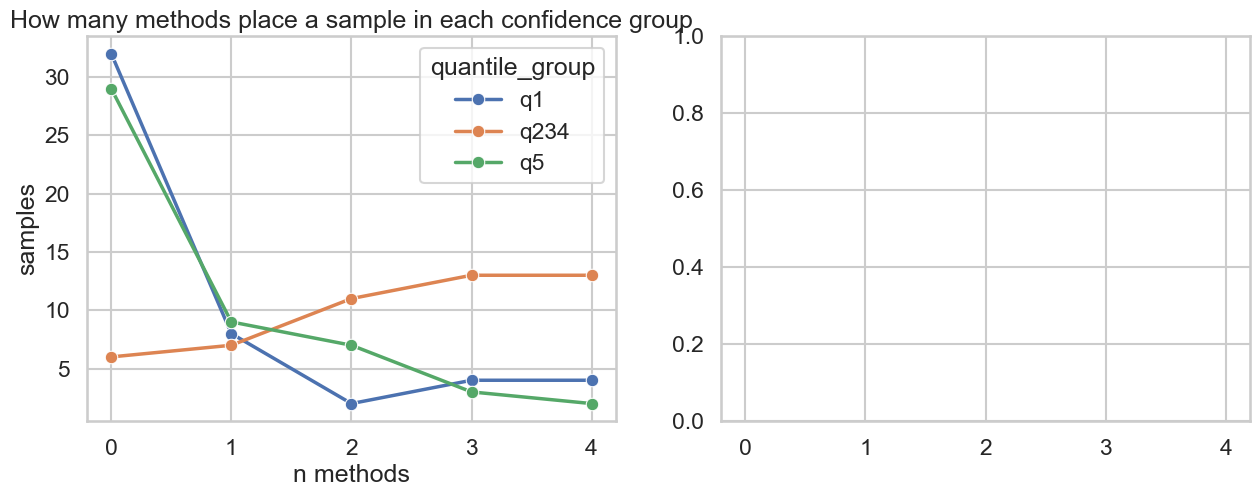

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

if "confidence_analysis_df" not in globals():
    raise ValueError("Run the confidence analysis cell first.")

grouped_confidence_cache_path = cache_file("confidence_grouped_quantiles.pkl")


def _build_grouped_confidence_bundle() -> dict[str, Any]:
    grouped = confidence_analysis_df.copy()
    grouped["quantile_group"] = np.select(
        [
            grouped["confidence_bin"].eq(1),
            grouped["confidence_bin"].isin([2, 3, 4]),
            grouped["confidence_bin"].eq(5),
        ],
        ["q1", "q234", "q5"],
        default=None,
    )
    grouped = grouped.dropna(subset=["quantile_group"]).copy()
    grouped["quantile_group"] = pd.Categorical(grouped["quantile_group"], categories=["q1", "q234", "q5"], ordered=True)

    method_rows: list[dict[str, Any]] = []
    for method_name, method_df in grouped.groupby("method", observed=True):
        total_rows = int(len(method_df))
        method_rows.append(
            {
                "method": str(method_name),
                "n_scored": total_rows,
                "q1_rows": int((method_df["quantile_group"] == "q1").sum()),
                "q234_rows": int((method_df["quantile_group"] == "q234").sum()),
                "q5_rows": int((method_df["quantile_group"] == "q5").sum()),
                "q1_share": float((method_df["quantile_group"] == "q1").mean()),
                "q234_share": float((method_df["quantile_group"] == "q234").mean()),
                "q5_share": float((method_df["quantile_group"] == "q5").mean()),
            }
        )

    method_counts_df = pd.DataFrame(method_rows).sort_values("method").reset_index(drop=True)
    confidence_summary_df = method_counts_df.copy()

    sample_counts_df = (
        grouped.groupby("row", observed=True)
        .agg(
            kind=("kind", "first"),
            true_label=("true_label", "first"),
            is_corrupted=("is_corrupted", "first"),
            q1_methods=("quantile_group", lambda series: int((series == "q1").sum())),
            q234_methods=("quantile_group", lambda series: int((series == "q234").sum())),
            q5_methods=("quantile_group", lambda series: int((series == "q5").sum())),
        )
        .reset_index()
    )

    def _trend_df(group_name: str) -> pd.DataFrame:
        count_col = f"{group_name}_methods"
        rows: list[dict[str, Any]] = []
        for n_methods in range(len(method_order) + 1):
            subset = sample_counts_df.loc[sample_counts_df[count_col] == n_methods]
            rows.append(
                {
                    "quantile_group": group_name,
                    "n_methods": n_methods,
                    "samples": int(len(subset)),
                    "mislabeled_rate": float(subset["is_corrupted"].mean()) if len(subset) else np.nan,
                    "mislabeled_samples": int(subset["is_corrupted"].sum()) if len(subset) else 0,
                }
            )
        return pd.DataFrame(rows)

    consensus_summary_df = pd.concat([_trend_df(group_name) for group_name in ["q1", "q234", "q5"]], ignore_index=True)
    consensus_distribution_df = consensus_summary_df[["quantile_group", "n_methods", "samples"]].copy()

    pairwise_group_matrices: dict[str, pd.DataFrame] = {}
    pairwise_rows: list[dict[str, Any]] = []
    for group_name in ["q1", "q234", "q5"]:
        sets_by_method = {
            method_name: set(
                grouped.loc[
                    (grouped["method"] == method_name) & (grouped["quantile_group"] == group_name),
                    "row",
                ].astype(int).tolist()
            )
            for method_name in method_order
        }
        matrix = _pairwise_jaccard(sets_by_method)
        pairwise_group_matrices[group_name] = matrix
        matrix_values = matrix.to_numpy(dtype=float)
        off_diag_mask = ~np.eye(matrix_values.shape[0], dtype=bool)
        off_diag = matrix_values[off_diag_mask]
        off_diag = off_diag[~np.isnan(off_diag)]
        pairwise_rows.append(
            {
                "quantile_group": group_name,
                "mean_off_diag_jaccard": float(np.mean(off_diag)) if len(off_diag) else np.nan,
                "min_off_diag_jaccard": float(np.min(off_diag)) if len(off_diag) else np.nan,
                "max_off_diag_jaccard": float(np.max(off_diag)) if len(off_diag) else np.nan,
            }
        )

    pairwise_summary_df = pd.DataFrame(pairwise_rows).sort_values("quantile_group").reset_index(drop=True)

    overall_summary = {
        "n_methods": int(len(method_order)),
        "n_rows": int(len(grouped)),
        "n_corrupted": int(grouped["is_corrupted"].sum()),
        "q1_rows_in_all_methods": int((sample_counts_df["q1_methods"] == len(method_order)).sum()),
        "q234_rows_in_all_methods": int((sample_counts_df["q234_methods"] == len(method_order)).sum()),
        "q5_rows_in_all_methods": int((sample_counts_df["q5_methods"] == len(method_order)).sum()),
        "q1_methods_vs_corrupted_spearman": float(sample_counts_df["q1_methods"].corr(sample_counts_df["is_corrupted"], method="spearman")),
        "q234_methods_vs_corrupted_spearman": float(sample_counts_df["q234_methods"].corr(sample_counts_df["is_corrupted"], method="spearman")),
        "q5_methods_vs_corrupted_spearman": float(sample_counts_df["q5_methods"].corr(sample_counts_df["is_corrupted"], method="spearman")),
    }

    return {
        "grouped_confidence_df": grouped,
        "method_counts_df": method_counts_df,
        "confidence_summary_df": confidence_summary_df,
        "sample_counts_df": sample_counts_df,
        "consensus_summary_df": consensus_summary_df,
        "consensus_distribution_df": consensus_distribution_df,
        "pairwise_summary_df": pairwise_summary_df,
        "pairwise_group_matrices": pairwise_group_matrices,
        "overall_summary": overall_summary,
    }


grouped_confidence_bundle = load_or_compute_cache(grouped_confidence_cache_path, _build_grouped_confidence_bundle)
grouped_confidence_df = grouped_confidence_bundle["grouped_confidence_df"]
method_counts_df = grouped_confidence_bundle["method_counts_df"]
confidence_summary_df = grouped_confidence_bundle["confidence_summary_df"]
sample_counts_df = grouped_confidence_bundle["sample_counts_df"]
consensus_summary_df = grouped_confidence_bundle["consensus_summary_df"]
consensus_distribution_df = grouped_confidence_bundle["consensus_distribution_df"]
pairwise_summary_df = grouped_confidence_bundle["pairwise_summary_df"]
pairwise_group_matrices = grouped_confidence_bundle["pairwise_group_matrices"]
overall_summary = grouped_confidence_bundle["overall_summary"]

print("Quantile-group confidence overlap analysis")
print("Q1 = lowest-confidence quantile, Q2-4 = middle 60%, Q5 = highest-confidence quantile")
display(method_counts_df)
display(pairwise_summary_df)
display(consensus_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
sns.lineplot(
    data=consensus_summary_df,
    x="n_methods",
    y="samples",
    hue="quantile_group",
    marker="o",
    linewidth=2.5,
    ax=axes[0],
)
axes[0].set_title("How many methods place a sample in each confidence group")
axes[0].set_xlabel("n methods")
axes[0].set_ylabel("samples")
axes[0].set_xticks(range(len(method_order) + 1))
axes[0].grid(axis="y", alpha=0.2)

sns.lineplot(
    data=consensus_summary_df,
    x="n_methods",
    y="mislabeled_rate",
    hue="quantile_group",
    marker="o",
    linewidth=2.5,
    ax=axes[1],
)
axes[1].set_title("Mislabeled rate vs number of methods in the group")
axes[1].set_xlabel("n methods")
axes[1].set_ylabel("mislabeled rate")
axes[1].set_xticks(range(len(method_order) + 1))
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend(title="group", loc="best")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, group_name, title, cmap in [
    (axes[0], "q1", "Pairwise overlap for Q1", "Blues"),
    (axes[1], "q234", "Pairwise overlap for Q2-4", "Oranges"),
    (axes[2], "q5", "Pairwise overlap for Q5", "Greens"),
]:
    sns.heatmap(pairwise_group_matrices[group_name], annot=True, fmt=".2f", cmap=cmap, vmin=0.0, vmax=1.0, square=True, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Rows in all methods for Q1: {overall_summary['q1_rows_in_all_methods']} / {len(sample_counts_df)}")
print(f"Rows in all methods for Q2-4: {overall_summary['q234_rows_in_all_methods']} / {len(sample_counts_df)}")
print(f"Rows in all methods for Q5: {overall_summary['q5_rows_in_all_methods']} / {len(sample_counts_df)}")
print("All comparisons use within-method quantile ranks, so raw confidence calibration does not matter here.")
print("A sample is considered mislabeled when is_corrupted=True.")

### OTHER SELF CONTAINED EXPS

Per-experiment cleanlab comparison


,method,base_accuracy,base_f1_macro,flagged_rows,precision,recall,f1,tp,fp,fn,tn,flag_rate
0,dinco_two_pass,0.84,0.767181,18,0.944444,0.653846,0.772727,17,1,9,23,0.36
1,confidence_x3,0.86,0.780519,16,1.000000,0.615385,0.761905,16,0,10,24,0.32
2,self_moe_two_pass,0.82,0.740559,19,0.894737,0.653846,0.755556,17,2,9,22,0.38
3,committee_standard,0.84,0.762969,17,0.941176,0.615385,0.744186,16,1,10,23,0.34


Best cleanlab combination by F1: dinco_two_pass (precision=0.944, recall=0.654, f1=0.773)


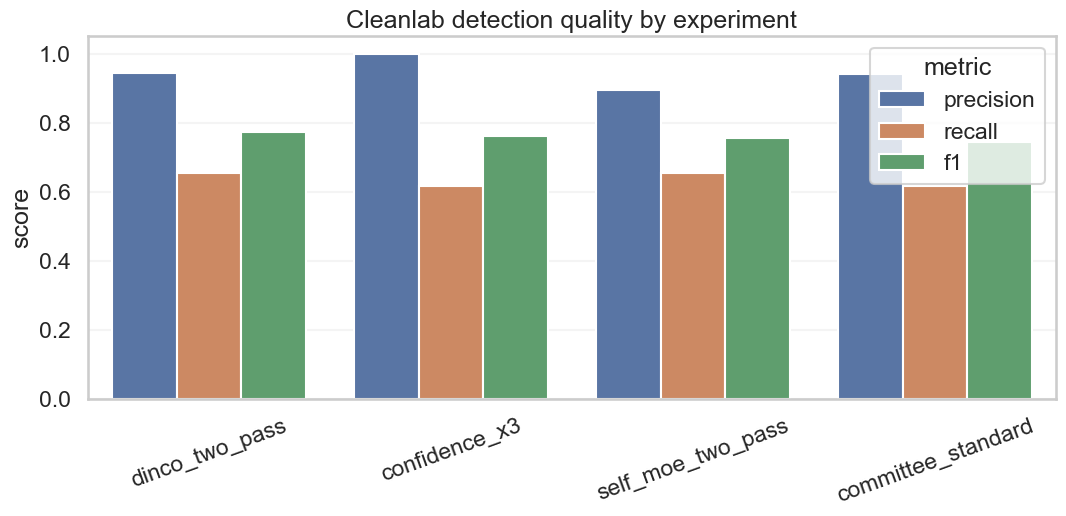

Corrupted vs flagged confusion matrix for committee_standard


is_flagged,not_flagged,flagged
is_corrupted,,
not_corrupted,23,1
corrupted,10,16


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")


def _outputs_to_pred_probs(outputs: list[dict[str, Any]]) -> np.ndarray:
    n_labels = len(ALLOWED_LABELS)
    if n_labels == 0:
        return np.zeros((len(outputs), 0), dtype=float)
    probs = np.full((len(outputs), n_labels), 1.0 / n_labels, dtype=float)
    if n_labels == 1:
        probs[:, 0] = 1.0
        return probs
    for row_idx, output in enumerate(outputs):
        label = output.get("label")
        confidence = output.get("confidence")
        if label not in LABEL_TO_IDX or confidence is None:
            continue
        try:
            confidence_value = float(confidence)
        except Exception:
            continue
        if not np.isfinite(confidence_value):
            continue
        confidence_value = float(np.clip(confidence_value, 0.0, 1.0))
        probs[row_idx, :] = (1.0 - confidence_value) / float(n_labels - 1)
        probs[row_idx, LABEL_TO_IDX[label]] = confidence_value
    return probs


def _avg_run_probs(runs: list[list[dict[str, Any]]]) -> np.ndarray:
    return np.mean([_outputs_to_pred_probs(run) for run in runs], axis=0)


cleanlab_specs = [
    {
        "method": "committee_standard",
        "pred_probs": committee_standard["pred_probs"],
        "base_accuracy": float(committee_standard["metrics"]["accuracy"]),
        "base_f1_macro": float(committee_standard["metrics"]["f1_macro"]),
    },
    {
        "method": "confidence_x3",
        "pred_probs": _avg_run_probs(confidence_x3["runs"]),
        "base_accuracy": float(confidence_x3["metrics"]["accuracy"]),
        "base_f1_macro": float(confidence_x3["metrics"]["f1_macro"]),
    },
    {
        "method": "dinco_two_pass",
        "pred_probs": _outputs_to_pred_probs(dinco["stage2_outputs"]),
        "base_accuracy": float(dinco["metrics"]["accuracy"]),
        "base_f1_macro": float(dinco["metrics"]["f1_macro"]),
    },
    {
        "method": "self_moe_two_pass",
        "pred_probs": _outputs_to_pred_probs(self_moe["stage2_outputs"]),
        "base_accuracy": float(self_moe["metrics"]["accuracy"]),
        "base_f1_macro": float(self_moe["metrics"]["f1_macro"]),
    },
]

cleanlab_tables_by_method: dict[str, pd.DataFrame] = {}
cleanlab_rows: list[dict[str, Any]] = []

for spec in cleanlab_specs:
    cleanlab_table = cleanlab_flag_table(train_eval_df, spec["pred_probs"], noisy_label_col="observed_label_name")
    cleanlab_tables_by_method[spec["method"]] = cleanlab_table
    metrics = detection_metrics(cleanlab_table)
    flagged = cleanlab_table["is_flagged"].astype(bool)
    corrupted = cleanlab_table["is_corrupted"].astype(bool)
    cleanlab_rows.append(
        {
            "method": spec["method"],
            "base_accuracy": spec["base_accuracy"],
            "base_f1_macro": spec["base_f1_macro"],
            "flagged_rows": int(metrics["flagged_rows"]),
            "precision": float(metrics["precision"]),
            "recall": float(metrics["recall"]),
            "f1": float(metrics["f1"]),
            "tp": int((flagged & corrupted).sum()),
            "fp": int((flagged & ~corrupted).sum()),
            "fn": int((~flagged & corrupted).sum()),
            "tn": int((~flagged & ~corrupted).sum()),
            "flag_rate": float(flagged.mean()),
        }
    )

cleanlab_summary_df = pd.DataFrame(cleanlab_rows).sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True)

print("Per-experiment cleanlab comparison")
display(cleanlab_summary_df)

best_cleanlab_row = cleanlab_summary_df.iloc[0]
print(f"Best cleanlab combination by F1: {best_cleanlab_row['method']} (precision={best_cleanlab_row['precision']:.3f}, recall={best_cleanlab_row['recall']:.3f}, f1={best_cleanlab_row['f1']:.3f})")

# Preserve the original baseline variables used elsewhere in the notebook.
cleanlab_standard_table = cleanlab_tables_by_method["committee_standard"]
cleanlab_standard_metrics = detection_metrics(cleanlab_standard_table)
cleanlab_display = (
    train_eval_df[["row", "kind", "true_label", "is_corrupted"]]
    .merge(cleanlab_standard_table[["row", "is_flagged"]], on="row", how="left")
    .sort_values("row")
    .reset_index(drop=True)
 )

fig, axis = plt.subplots(figsize=(11, 5.5))
plot_df = cleanlab_summary_df.melt(id_vars=["method"], value_vars=["precision", "recall", "f1"], var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="method", y="score", hue="metric", ax=axis)
axis.set_ylim(0, 1.05)
axis.set_xlabel("")
axis.set_ylabel("score")
axis.set_title("Cleanlab detection quality by experiment")
axis.tick_params(axis="x", rotation=20)
axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("Corrupted vs flagged confusion matrix for committee_standard")
display(cleanlab_confusion(cleanlab_standard_table))

In [41]:
artifacts_to_save = [
    ("train_eval_df.pkl", train_eval_df),
    ("committee_standard.pkl", committee_standard),
    ("cleanlab_standard.pkl", {"table": cleanlab_standard_table, "metrics": cleanlab_standard_metrics}),
    ("confidence_x3.pkl", confidence_x3),
    ("dinco_two_pass.pkl", dinco),
    ("self_moe_two_pass.pkl", self_moe),
    ("confidence_overlap.pkl", {
        "confidence_analysis_df": confidence_analysis_df,
        "confidence_summary_df": confidence_summary_df,
        "pairwise_summary_df": pairwise_summary_df,
        "consensus_summary_df": consensus_summary_df,
        "method_counts_df": method_counts_df,
        "consensus_distribution_df": consensus_distribution_df,
        "overall_summary": overall_summary,
    }),
    ("cleanlab_experiment_suite.pkl", {
        "summary_df": cleanlab_summary_df,
        "tables_by_method": cleanlab_tables_by_method,
    }),
    ("experiment_summary.pkl", experiment_summary),
]

for artifact_name, artifact_value in artifacts_to_save:
    artifact_path = cache_file(artifact_name)
    save_cache(artifact_path, artifact_value)
    print(f"Saved {artifact_name} -> {artifact_path}")

Saved train_eval_df.pkl -> d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\train_eval_df.pkl
Saved committee_standard.pkl -> d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\committee_standard.pkl
Saved cleanlab_standard.pkl -> d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\cleanlab_standard.pkl
Saved confidence_x3.pkl -> d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\confidence_x3.pkl
Saved dinco_two_pass.pkl -> d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\dinco_two_pass.pkl
Saved self_moe_two_pass.pkl -> d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\self_moe_two_pass.pkl
Saved confidence_overlap.pkl -> d:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\samples_cleaning\confidence_overlap.pkl
Saved cleanlab_experiment_suite.pkl -> d:\Cod

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

,kind,n,mislabeled_rate,mean_perplexity,median_perplexity
0,clean,24,0.0,301.779696,91.414970
1,correlated_label,9,1.0,184.628401,161.428696
2,random_label,9,1.0,118.250872,73.977608
3,text_word_dropout,8,1.0,232.542335,148.103172


Lowest perplexity examples


,row,kind,true_label,is_corrupted,perplexity,ppl_quantile,ppl_group,text
0,7,random_label,background,True,17.059074,1,Q1,Streptococcus mutans is one of the most common cariogenic microorganisms .
1,36,clean,results,False,19.309055,1,Q1,"The incidence of bronchopulmonary dysplasia was @ % in the budesonide group versus @ % in the placebo group ( relative risk , stratified..."
2,24,text_word_dropout,objective,True,20.910183,1,Q1,The aim of this study was to investigate the effect of a single dose of Brazil nuts on the inflammatory markers of healthy individuals .
3,22,text_word_dropout,methods,True,25.714304,1,Q1,Seven hundred and seventy-three adults who lost at least @ % of their body weights were randomized to one of five ad libitum diets for @...
4,40,clean,methods,False,32.909466,1,Q1,A randomized controlled trial was carried out to evaluate the impact of the two different hepatic transection techniques .
5,46,clean,results,False,34.929836,1,Q1,No clinical differences were found between two groups and no correlations between clinical and radiological results were found in any pa...
6,3,random_label,objective,True,37.245186,1,Q1,Their effectiveness is unproved in randomized controlled trials ( RCTs ) .
7,28,clean,results,False,42.909657,1,Q1,"For peak bilirubin levels greater than @ mg/dl , the positive predictive value of a baseline bilirubin level of @ mg/dl or higher with h..."


Highest perplexity examples


,row,kind,true_label,is_corrupted,perplexity,ppl_quantile,ppl_group,text
0,26,clean,methods,False,3934.324219,5,Q5,All received routine treatment .
1,35,clean,results,False,953.544495,5,Q5,"Among participants who undertook both measures , @ % recorded a high RBGT and high AUSDRISK ."
2,18,text_word_dropout,conclusions,True,640.900330,5,Q5,MBHD favorably improved early recovery of neural functions of CSCS patients ( @ months after surgery ) .
3,17,correlated_label,results,True,598.813599,5,Q5,"Those given ATG had lower HCV recurrence ( @ vs @ % , p = @ ) ."
4,19,text_word_dropout,methods,True,517.852295,5,Q5,Secondary outcomes included new MDRO acquisitions and new clinically defined device-associated infections .
5,6,random_label,methods,True,384.707642,5,Q5,"Three vignettes described different type of drug dependence meeting diagnostic criteria , and the fourth depicted a `` normal person . ''"
6,20,text_word_dropout,conclusions,True,289.892975,5,Q5,"IGF-@R targeting may merit further evaluation in this disease in selected populations , but combination with docetaxel is not recommended ."
7,39,clean,conclusions,False,278.147858,5,Q5,Combined laser acupuncture and desmopressin is a promising and valid option to manage resistant cases of MNE .


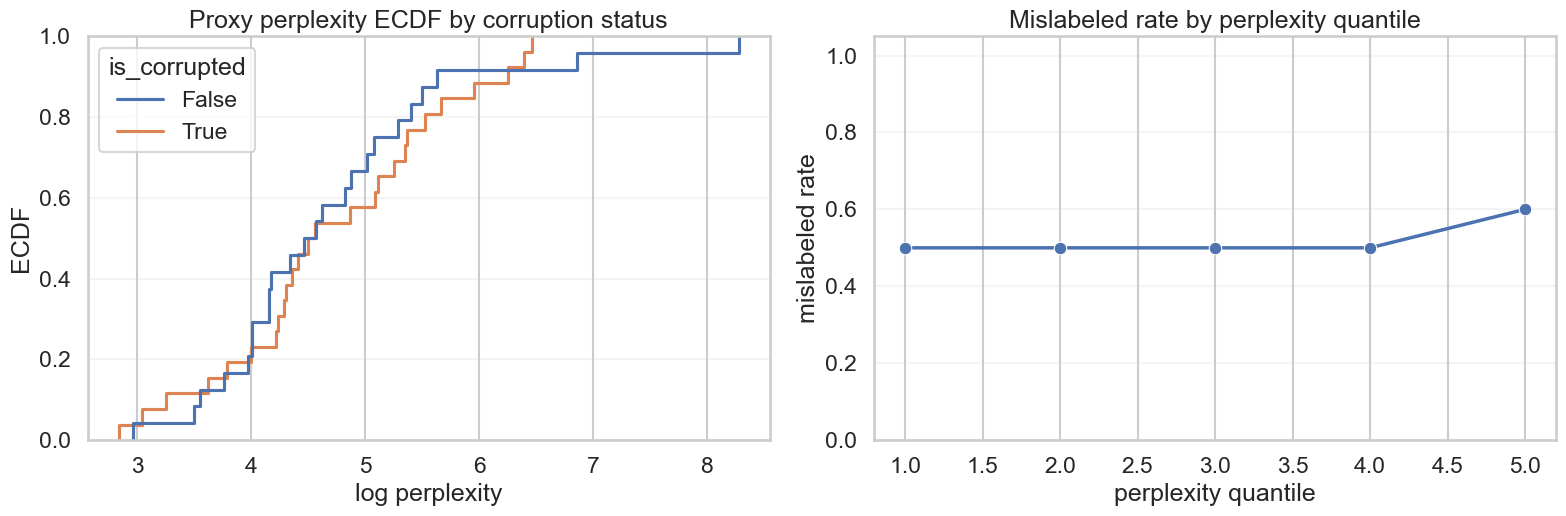

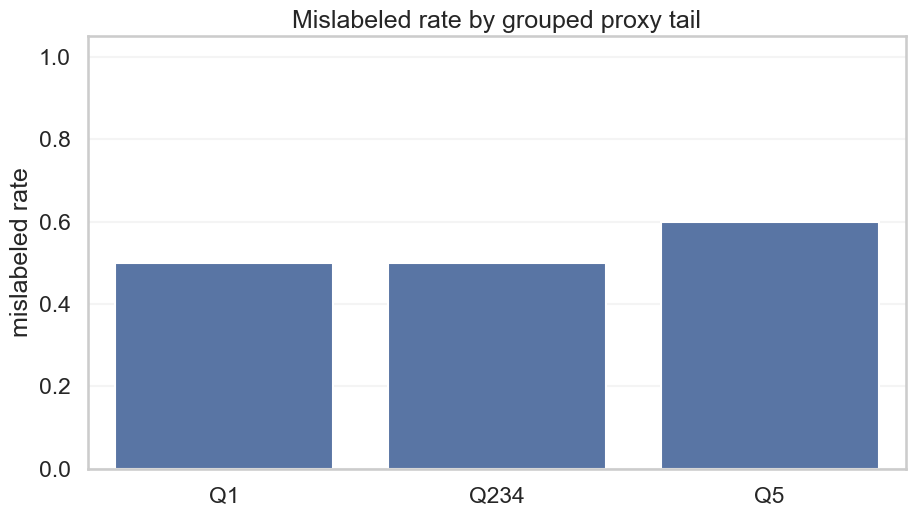

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

sns.set_theme(style="whitegrid", context="talk")

small_proxy_filtering_cache_path = cache_file("small_proxy_filtering_gpt2.pkl")


def _calculate_perplexity(text: str, model: torch.nn.Module, tokenizer: GPT2TokenizerFast, device: torch.device) -> float:
    encodings = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    input_ids = encodings.input_ids.to(device)
    target_ids = input_ids.clone()
    with torch.no_grad():
        outputs = model(input_ids, labels=target_ids)
        neg_log_likelihood = outputs.loss
    return float(torch.exp(neg_log_likelihood).item())


def _build_small_proxy_filtering_bundle() -> dict[str, Any]:
    model_id = "gpt2"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    tokenizer.pad_token = tokenizer.eos_token
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    model.eval()

    records: list[dict[str, Any]] = []
    for row in train_eval_df.itertuples(index=False):
        text = str(getattr(row, "text"))
        perplexity = _calculate_perplexity(text, model, tokenizer, device)
        records.append(
            {
                "row": int(getattr(row, "row")),
                "kind": str(getattr(row, "kind")),
                "true_label": str(getattr(row, "true_label")),
                "is_corrupted": bool(getattr(row, "is_corrupted")),
                "perplexity": float(perplexity),
                "text": text,
            }
        )

    proxy_df = pd.DataFrame(records).sort_values("row").reset_index(drop=True)
    proxy_df["log_perplexity"] = np.log(proxy_df["perplexity"])
    proxy_df["ppl_rank"] = proxy_df["log_perplexity"].rank(method="first")
    proxy_df["ppl_quantile"] = pd.qcut(proxy_df["ppl_rank"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
    proxy_df["ppl_group"] = np.select(
        [proxy_df["ppl_quantile"].eq(1), proxy_df["ppl_quantile"].isin([2, 3, 4]), proxy_df["ppl_quantile"].eq(5)],
        ["Q1", "Q234", "Q5"],
        default="Q234",
    )
    proxy_df["ppl_group"] = pd.Categorical(proxy_df["ppl_group"], categories=["Q1", "Q234", "Q5"], ordered=True)
    proxy_df["flag_low"] = proxy_df["ppl_quantile"].eq(1)
    proxy_df["flag_high"] = proxy_df["ppl_quantile"].eq(5)
    proxy_df["flag_either_tail"] = proxy_df["flag_low"] | proxy_df["flag_high"]

    def _detection_metrics(flag_series: pd.Series) -> dict[str, float]:
        flagged = flag_series.astype(bool)
        corrupted = proxy_df["is_corrupted"].astype(bool)
        tp = int((flagged & corrupted).sum())
        fp = int((flagged & ~corrupted).sum())
        fn = int((~flagged & corrupted).sum())
        precision = float(tp / (tp + fp)) if (tp + fp) else 0.0
        recall = float(tp / (tp + fn)) if (tp + fn) else 0.0
        f1 = float((2 * precision * recall / (precision + recall))) if (precision + recall) else 0.0
        return {
            "flagged_rows": int(flagged.sum()),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "flag_rate": float(flagged.mean()),
        }

    quantile_summary_df = (
        proxy_df.groupby("ppl_quantile", observed=True)
        .agg(
            n=("row", "size"),
            mislabeled_rate=("is_corrupted", "mean"),
            mean_perplexity=("perplexity", "mean"),
            median_perplexity=("perplexity", "median"),
        )
        .reset_index()
        .sort_values("ppl_quantile")
        .reset_index(drop=True)
    )

    group_summary_df = (
        proxy_df.groupby("ppl_group", observed=True)
        .agg(
            n=("row", "size"),
            mislabeled_rate=("is_corrupted", "mean"),
            mean_perplexity=("perplexity", "mean"),
            median_perplexity=("perplexity", "median"),
        )
        .reset_index()
        .sort_values("ppl_group")
        .reset_index(drop=True)
    )

    filter_summary_df = pd.DataFrame([
        {"strategy": "low_tail_Q1", **_detection_metrics(proxy_df["flag_low"])},
        {"strategy": "high_tail_Q5", **_detection_metrics(proxy_df["flag_high"])},
        {"strategy": "either_tail_Q1_or_Q5", **_detection_metrics(proxy_df["flag_either_tail"])},
    ])

    kind_summary_df = (
        proxy_df.groupby("kind", observed=True)
        .agg(
            n=("row", "size"),
            mislabeled_rate=("is_corrupted", "mean"),
            mean_perplexity=("perplexity", "mean"),
            median_perplexity=("perplexity", "median"),
        )
        .reset_index()
    )

    low_examples = proxy_df.sort_values("perplexity", ascending=True).head(8).reset_index(drop=True)
    high_examples = proxy_df.sort_values("perplexity", ascending=False).head(8).reset_index(drop=True)

    return {
        "model_id": model_id,
        "device": str(device),
        "proxy_df": proxy_df,
        "quantile_summary_df": quantile_summary_df,
        "group_summary_df": group_summary_df,
        "filter_summary_df": filter_summary_df,
        "kind_summary_df": kind_summary_df,
        "low_examples": low_examples,
        "high_examples": high_examples,
        "low_cutoff": float(proxy_df.loc[proxy_df["flag_low"], "log_perplexity"].max()) if proxy_df["flag_low"].any() else np.nan,
        "high_cutoff": float(proxy_df.loc[proxy_df["flag_high"], "log_perplexity"].min()) if proxy_df["flag_high"].any() else np.nan,
    }


small_proxy_bundle = load_or_compute_cache(small_proxy_filtering_cache_path, _build_small_proxy_filtering_bundle)
proxy_df = small_proxy_bundle["proxy_df"]
quantile_summary_df = small_proxy_bundle["quantile_summary_df"]
group_summary_df = small_proxy_bundle["group_summary_df"]
filter_summary_df = small_proxy_bundle["filter_summary_df"]
kind_summary_df = small_proxy_bundle["kind_summary_df"]
low_examples = small_proxy_bundle["low_examples"]
high_examples = small_proxy_bundle["high_examples"]

print("Small proxy filtering experiment")
print(f"model={small_proxy_bundle['model_id']} | device={small_proxy_bundle['device']}")
print("Quantiles are computed within the sample, so the proxy is self-normalized.")
print(f"low-tail cutoff (log perplexity) = {small_proxy_bundle['low_cutoff']:.3f}")
print(f"high-tail cutoff (log perplexity) = {small_proxy_bundle['high_cutoff']:.3f}")

display(filter_summary_df)
display(quantile_summary_df)
display(group_summary_df)
display(kind_summary_df)

print("Lowest perplexity examples")
display(low_examples[["row", "kind", "true_label", "is_corrupted", "perplexity", "ppl_quantile", "ppl_group", "text"]].assign(text=lambda frame: frame["text"].astype(str).str.slice(0, 150)))

print("Highest perplexity examples")
display(high_examples[["row", "kind", "true_label", "is_corrupted", "perplexity", "ppl_quantile", "ppl_group", "text"]].assign(text=lambda frame: frame["text"].astype(str).str.slice(0, 150)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.ecdfplot(data=proxy_df, x="log_perplexity", hue="is_corrupted", ax=axes[0])
axes[0].set_title("Proxy perplexity ECDF by corruption status")
axes[0].set_xlabel("log perplexity")
axes[0].set_ylabel("ECDF")
axes[0].grid(axis="y", alpha=0.2)

sns.lineplot(data=quantile_summary_df, x="ppl_quantile", y="mislabeled_rate", marker="o", linewidth=2.5, ax=axes[1])
axes[1].set_title("Mislabeled rate by perplexity quantile")
axes[1].set_xlabel("perplexity quantile")
axes[1].set_ylabel("mislabeled rate")
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(9.5, 5.5))
sns.barplot(data=group_summary_df, x="ppl_group", y="mislabeled_rate", ax=axis)
axis.set_title("Mislabeled rate by grouped proxy tail")
axis.set_xlabel("")
axis.set_ylabel("mislabeled rate")
axis.set_ylim(0, 1.05)
axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

Prior-based filtering vs GPT-2 proxy filtering
Prior corpus sample size: 100
All comparisons are quantile-based within each method, so raw score calibration is not assumed.


,method,n,roc_auc,spearman_r,mean_score_corrupted,mean_score_clean,q1_mislabeled_rate,q234_mislabeled_rate,q5_mislabeled_rate,q5_precision,q5_recall,q5_f1,q5_flag_rate
0,prior_frequency,50,0.544872,0.077674,1.280073,1.116143,0.4,0.5,0.7,0.7,0.269231,0.388889,0.2
1,gpt2_perplexity,50,0.541667,0.072125,4.718663,4.706938,0.5,0.5,0.6,0.6,0.230769,0.333333,0.2


,method,score_quantile,n,mislabeled_rate,mean_score,median_score
0,gpt2_perplexity,1,10,0.5,3.426888,3.523551
1,gpt2_perplexity,2,10,0.5,4.153420,4.163218
2,gpt2_perplexity,3,10,0.5,4.549540,4.527382
3,gpt2_perplexity,4,10,0.5,5.182986,5.183679
4,gpt2_perplexity,5,10,0.6,6.252343,6.101087
5,prior_frequency,1,10,0.4,0.352565,0.335001
6,prior_frequency,2,10,0.6,0.717724,0.691133
7,prior_frequency,3,10,0.5,1.009749,1.022380
8,prior_frequency,4,10,0.4,1.503076,1.442768
9,prior_frequency,5,10,0.7,2.423820,2.195125


,method,score_group,n,mislabeled_rate,mean_score,median_score
0,gpt2_perplexity,Q1,10,0.5,3.426888,3.523551
1,gpt2_perplexity,Q234,30,0.5,4.628648,4.527382
2,gpt2_perplexity,Q5,10,0.6,6.252343,6.101087
3,prior_frequency,Q1,10,0.4,0.352565,0.335001
4,prior_frequency,Q234,30,0.5,1.076850,1.022380
5,prior_frequency,Q5,10,0.7,2.423820,2.195125


,q5_methods,samples,mislabeled_rate,mislabeled_samples
0,0,32,0.46875,15
1,1,16,0.56250,9
2,2,2,1.00000,2


,method,q5_rows
0,gpt2_perplexity,10
1,prior_frequency,10


,gpt2_perplexity,prior_frequency
gpt2_perplexity,1.000000,0.111111
prior_frequency,0.111111,1.000000


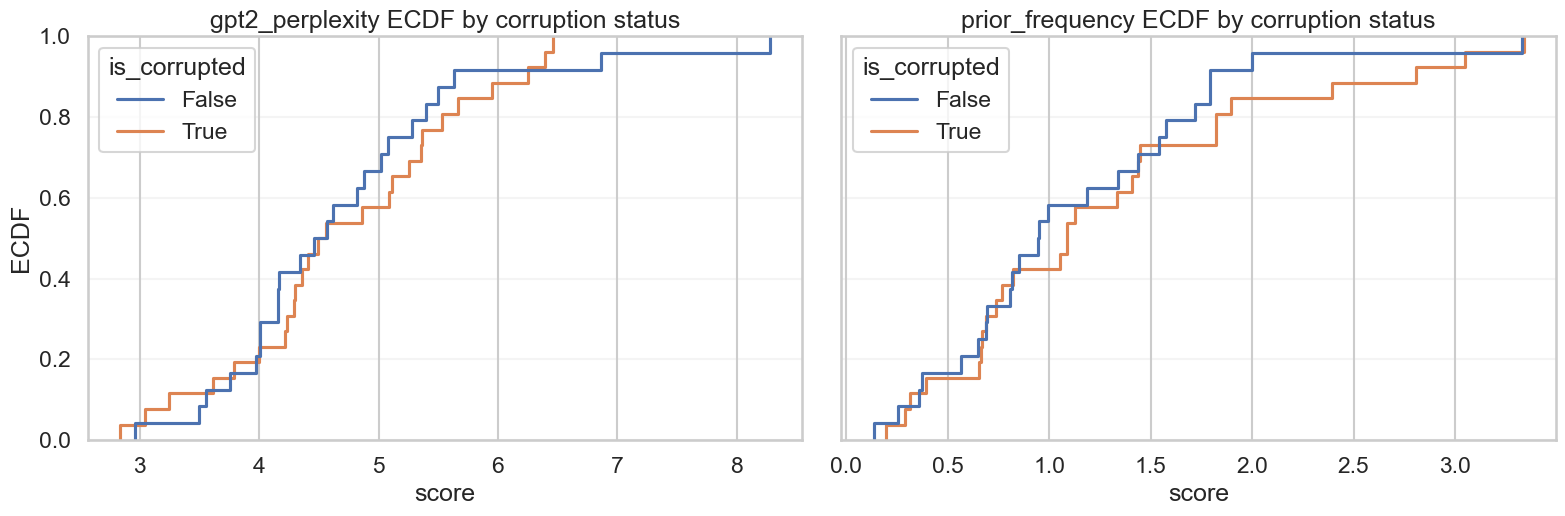

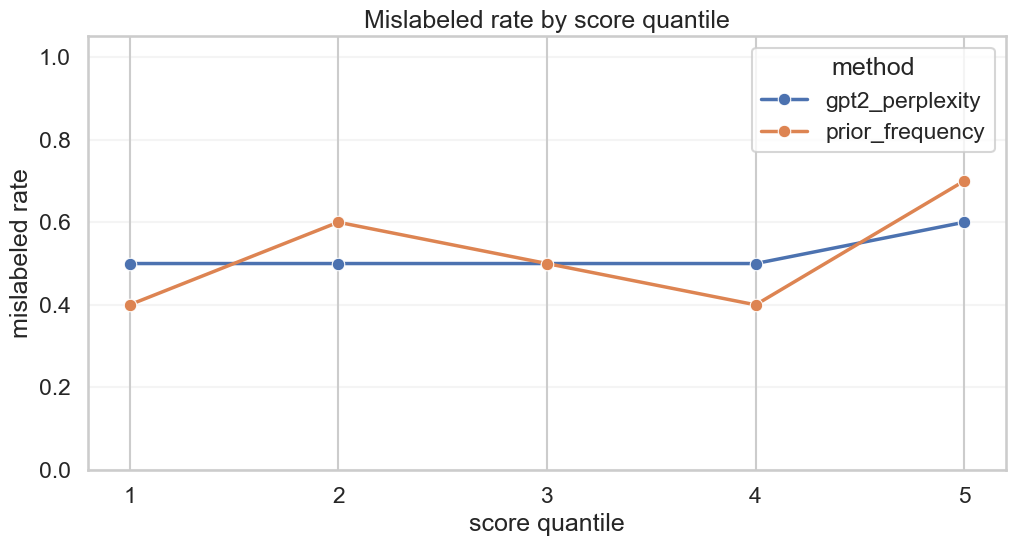

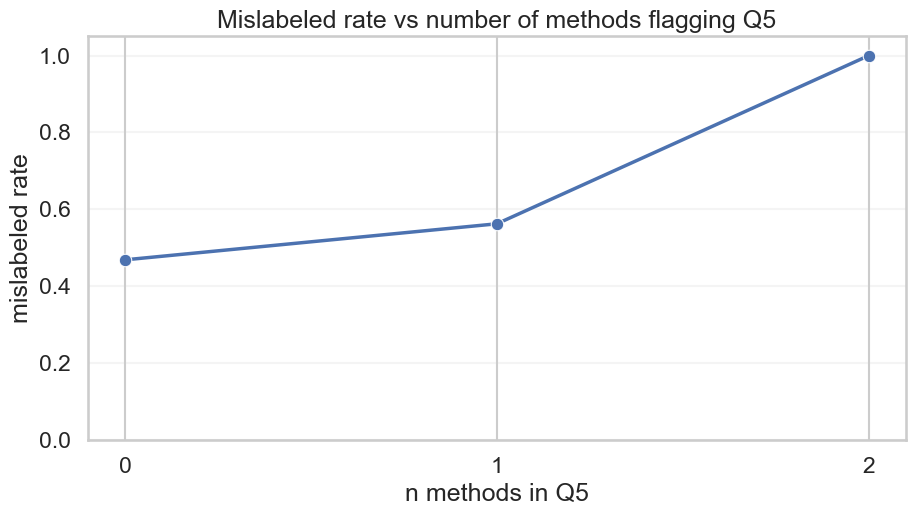

Most suspicious examples by prior-based score


,row,kind,true_label,is_corrupted,prior_score,score_quantile,score_group,text
0,4,random_label,results,True,3.337267,5,Q5,Levels of @F@ and @E@ declined exponentially thereafter with similar estimated half-lives ( @ and @ hours ) .
1,36,clean,results,False,3.330348,5,Q5,"The incidence of bronchopulmonary dysplasia was @ % in the budesonide group versus @ % in the placebo group ( relative risk , stratified..."
2,17,correlated_label,results,True,3.047539,5,Q5,"Those given ATG had lower HCV recurrence ( @ vs @ % , p = @ ) ."
3,8,random_label,results,True,2.805067,5,Q5,"Both scores were associated with death or stroke ( hazard ratio -LSB- HR -RSB- , @ ; @ % confidence interval -LSB- CI -RSB- , @-@ @ for ..."
4,14,correlated_label,results,True,2.393400,5,Q5,"In @years , @ % ( CAL+BOP ) and @ % ( PD+BOP ) of healthy sites developed chronic periodontitis ."
5,34,clean,methods,False,1.996851,5,Q5,One hundred forty patients scheduled for laparoscopic ovarian cystectomy .
6,13,correlated_label,results,True,1.893468,5,Q5,"At the @-week visit , half ( @ % ) of the mothers who had enrolled in the study had applied for the CSG on behalf of their children , wh..."
7,5,random_label,conclusions,True,1.821934,5,Q5,This trial was registered with the Australian and New Zealand Clinical Trials Registry Unique Identifier : ACTRN@ http://www.anzctr.org....


Most suspicious examples by GPT-2 perplexity


,row,kind,true_label,is_corrupted,log_perplexity,ppl_quantile,ppl_group,text
0,26,clean,methods,False,8.277494,5,Q5,All received routine treatment .
1,35,clean,results,False,6.860186,5,Q5,"Among participants who undertook both measures , @ % recorded a high RBGT and high AUSDRISK ."
2,18,text_word_dropout,conclusions,True,6.462874,5,Q5,MBHD favorably improved early recovery of neural functions of CSCS patients ( @ months after surgery ) .
3,17,correlated_label,results,True,6.394950,5,Q5,"Those given ATG had lower HCV recurrence ( @ vs @ % , p = @ ) ."
4,19,text_word_dropout,methods,True,6.249690,5,Q5,Secondary outcomes included new MDRO acquisitions and new clinically defined device-associated infections .
5,6,random_label,methods,True,5.952484,5,Q5,"Three vignettes described different type of drug dependence meeting diagnostic criteria , and the fourth depicted a `` normal person . ''"
6,20,text_word_dropout,conclusions,True,5.669512,5,Q5,"IGF-@R targeting may merit further evaluation in this disease in selected populations , but combination with docetaxel is not recommended ."
7,39,clean,conclusions,False,5.628153,5,Q5,Combined laser acupuncture and desmopressin is a promising and valid option to manage resistant cases of MNE .


In [24]:
from collections import Counter
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from transformers import GPT2TokenizerFast

sns.set_theme(style="whitegrid", context="talk")

prior_based_filtering_cache_path = cache_file("prior_based_filtering.pkl")
prior_vs_gpt2_cache_path = cache_file("prior_vs_gpt2_comparison.pkl")
gpt2_proxy_cache_path = cache_file("small_proxy_filtering_gpt2.pkl")


def _robust_z(series: pd.Series) -> pd.Series:
    median = float(series.median())
    mad = float((series - median).abs().median())
    scale = 1.4826 * mad if mad > 0 else float(series.std(ddof=0))
    if not np.isfinite(scale) or scale == 0.0:
        scale = 1.0
    return (series - median) / scale


def _load_gpt2_bundle() -> dict[str, Any]:
    if "small_proxy_bundle" in globals():
        return small_proxy_bundle
    if gpt2_proxy_cache_path.exists():
        return load_cache(gpt2_proxy_cache_path)
    raise ValueError("Run the GPT-2 proxy filtering cell first so its cache is available.")


def _build_prior_based_bundle() -> dict[str, Any]:
    model_id = "gpt2"
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    tokenizer.pad_token = tokenizer.eos_token

    prior_corpus_n = min(len(train_df), max(200, int(round(len(train_df) * 0.01))))
    if "stratified_take" in globals():
        prior_corpus_df = stratified_take(train_df, prior_corpus_n, label_col="true_label", seed=SEED).reset_index(drop=True)
    else:
        prior_corpus_df = train_df.sample(n=prior_corpus_n, random_state=SEED).reset_index(drop=True)

    token_counts: Counter[int] = Counter()
    total_token_count = 0
    for text in prior_corpus_df["text"].astype(str).tolist():
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        token_counts.update(token_ids)
        total_token_count += len(token_ids)

    if total_token_count == 0:
        raise ValueError("Could not build token priors because the prior corpus is empty.")

    token_priors = {token_id: count / total_token_count for token_id, count in token_counts.items()}

    records: list[dict[str, Any]] = []
    for row in train_eval_df.itertuples(index=False):
        text = str(getattr(row, "text"))
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        token_priors_in_text = np.asarray([token_priors.get(token_id, 0.0) for token_id in token_ids], dtype=float)
        if len(token_priors_in_text):
            prior_mu = float(token_priors_in_text.mean())
            prior_sigma = float(token_priors_in_text.std())
            token_count = int(len(token_priors_in_text))
        else:
            prior_mu = 0.0
            prior_sigma = 0.0
            token_count = 0
        records.append(
            {
                "row": int(getattr(row, "row")),
                "kind": str(getattr(row, "kind")),
                "true_label": str(getattr(row, "true_label")),
                "is_corrupted": bool(getattr(row, "is_corrupted")),
                "prior_mu": prior_mu,
                "prior_sigma": prior_sigma,
                "token_count": token_count,
                "text": text,
            }
        )

    prior_df = pd.DataFrame(records).sort_values("row").reset_index(drop=True)
    prior_df["mu_z"] = _robust_z(prior_df["prior_mu"])
    prior_df["sigma_z"] = _robust_z(prior_df["prior_sigma"])
    prior_df["prior_score"] = np.sqrt(prior_df["mu_z"] ** 2 + prior_df["sigma_z"] ** 2)
    prior_df["score_rank"] = prior_df["prior_score"].rank(method="first")
    prior_df["score_quantile"] = pd.qcut(prior_df["score_rank"], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
    prior_df["score_group"] = np.select(
        [
            prior_df["score_quantile"].eq(1),
            prior_df["score_quantile"].isin([2, 3, 4]),
            prior_df["score_quantile"].eq(5),
        ],
        ["Q1", "Q234", "Q5"],
        default="Q234",
    )
    prior_df["score_group"] = pd.Categorical(prior_df["score_group"], categories=["Q1", "Q234", "Q5"], ordered=True)

    quantile_summary_df = (
        prior_df.groupby("score_quantile", observed=True)
        .agg(
            n=("row", "size"),
            mislabeled_rate=("is_corrupted", "mean"),
            mean_score=("prior_score", "mean"),
            median_score=("prior_score", "median"),
        )
        .reset_index()
        .sort_values("score_quantile")
        .reset_index(drop=True)
    )

    group_summary_df = (
        prior_df.groupby("score_group", observed=True)
        .agg(
            n=("row", "size"),
            mislabeled_rate=("is_corrupted", "mean"),
            mean_score=("prior_score", "mean"),
            median_score=("prior_score", "median"),
        )
        .reset_index()
        .sort_values("score_group")
        .reset_index(drop=True)
    )

    q5_flag = prior_df["score_quantile"].eq(5)
    corrupted = prior_df["is_corrupted"].astype(bool)
    tp = int((q5_flag & corrupted).sum())
    fp = int((q5_flag & ~corrupted).sum())
    fn = int((~q5_flag & corrupted).sum())
    precision = float(tp / (tp + fp)) if (tp + fp) else 0.0
    recall = float(tp / (tp + fn)) if (tp + fn) else 0.0
    f1 = float(2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    filter_summary_df = pd.DataFrame([
        {
            "strategy": "high_tail_Q5",
            "flagged_rows": int(q5_flag.sum()),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "flag_rate": float(q5_flag.mean()),
        }
    ])

    low_examples = prior_df.sort_values("prior_score", ascending=True).head(8).reset_index(drop=True)
    high_examples = prior_df.sort_values("prior_score", ascending=False).head(8).reset_index(drop=True)

    return {
        "model_id": model_id,
        "prior_corpus_n": int(prior_corpus_n),
        "prior_df": prior_df,
        "quantile_summary_df": quantile_summary_df,
        "group_summary_df": group_summary_df,
        "filter_summary_df": filter_summary_df,
        "low_examples": low_examples,
        "high_examples": high_examples,
    }


prior_bundle = load_or_compute_cache(prior_based_filtering_cache_path, _build_prior_based_bundle)
gpt2_bundle = _load_gpt2_bundle()


def _standardize_proxy_frame(method_name: str, frame: pd.DataFrame, *, score_col: str, quantile_col: str, group_col: str) -> pd.DataFrame:
    out = frame[["row", "kind", "true_label", "is_corrupted", score_col, quantile_col, group_col]].copy()
    out = out.rename(
        columns={
            score_col: "score",
            quantile_col: "score_quantile",
            group_col: "score_group",
        }
    )
    out["method"] = method_name
    out["score_quantile"] = pd.to_numeric(out["score_quantile"], errors="coerce").astype(int)
    out["score_group"] = out["score_group"].astype(str)
    out["is_corrupted"] = out["is_corrupted"].astype(bool)
    out["corrupted_numeric"] = out["is_corrupted"].astype(int)
    return out


gpt2_df = _standardize_proxy_frame(
    "gpt2_perplexity",
    gpt2_bundle["proxy_df"],
    score_col="log_perplexity",
    quantile_col="ppl_quantile",
    group_col="ppl_group",
)

prior_df = _standardize_proxy_frame(
    "prior_frequency",
    prior_bundle["prior_df"],
    score_col="prior_score",
    quantile_col="score_quantile",
    group_col="score_group",
)

analysis_df = pd.concat([gpt2_df, prior_df], ignore_index=True)


def _method_summary(method_df: pd.DataFrame) -> dict[str, Any]:
    corrupted = method_df["is_corrupted"].astype(int)
    score = method_df["score"].astype(float)
    q5_flag = method_df["score_quantile"].eq(5)
    q1_flag = method_df["score_quantile"].eq(1)
    q234_flag = method_df["score_quantile"].isin([2, 3, 4])
    try:
        roc_auc = float(roc_auc_score(corrupted, score))
    except Exception:
        roc_auc = np.nan
    q5_tp = int((q5_flag & method_df["is_corrupted"]).sum())
    q5_fp = int((q5_flag & ~method_df["is_corrupted"]).sum())
    q5_fn = int((~q5_flag & method_df["is_corrupted"]).sum())
    q5_precision = float(q5_tp / (q5_tp + q5_fp)) if (q5_tp + q5_fp) else 0.0
    q5_recall = float(q5_tp / (q5_tp + q5_fn)) if (q5_tp + q5_fn) else 0.0
    q5_f1 = float(2 * q5_precision * q5_recall / (q5_precision + q5_recall)) if (q5_precision + q5_recall) else 0.0
    return {
        "method": str(method_df["method"].iloc[0]),
        "n": int(len(method_df)),
        "roc_auc": roc_auc,
        "spearman_r": float(score.corr(corrupted, method="spearman")),
        "mean_score_corrupted": float(score[method_df["is_corrupted"]].mean()),
        "mean_score_clean": float(score[~method_df["is_corrupted"]].mean()),
        "q1_mislabeled_rate": float(method_df.loc[q1_flag, "is_corrupted"].mean()) if q1_flag.any() else np.nan,
        "q234_mislabeled_rate": float(method_df.loc[q234_flag, "is_corrupted"].mean()) if q234_flag.any() else np.nan,
        "q5_mislabeled_rate": float(method_df.loc[q5_flag, "is_corrupted"].mean()) if q5_flag.any() else np.nan,
        "q5_precision": q5_precision,
        "q5_recall": q5_recall,
        "q5_f1": q5_f1,
        "q5_flag_rate": float(q5_flag.mean()),
    }


method_summary_df = (
    pd.DataFrame([_method_summary(method_df) for _, method_df in analysis_df.groupby("method", observed=True)])
    .sort_values(["q5_f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
 )

quantile_summary_df = (
    analysis_df.groupby(["method", "score_quantile"], observed=True)
    .agg(
        n=("row", "size"),
        mislabeled_rate=("is_corrupted", "mean"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
    )
    .reset_index()
    .sort_values(["method", "score_quantile"])
)

group_summary_df = (
    analysis_df.groupby(["method", "score_group"], observed=True)
    .agg(
        n=("row", "size"),
        mislabeled_rate=("is_corrupted", "mean"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
    )
    .reset_index()
    .sort_values(["method", "score_group"])
)

q5_counts_df = (
    analysis_df.assign(q5_flag=analysis_df["score_quantile"].eq(5))
    .groupby("row", observed=True)
    .agg(
        kind=("kind", "first"),
        true_label=("true_label", "first"),
        is_corrupted=("is_corrupted", "first"),
        q5_methods=("q5_flag", "sum"),
    )
    .reset_index()
 )

q5_consensus_df = (
    q5_counts_df.groupby("q5_methods", observed=True)
    .agg(
        samples=("row", "size"),
        mislabeled_rate=("is_corrupted", "mean"),
        mislabeled_samples=("is_corrupted", "sum"),
    )
    .reset_index()
    .sort_values("q5_methods")
 )

q5_overlap_counts = analysis_df.assign(q5_flag=analysis_df["score_quantile"].eq(5)).groupby("method", observed=True).agg(q5_rows=("q5_flag", "sum")).reset_index()

q5_sets = {
    method_name: set(method_df.loc[method_df["score_quantile"].eq(5), "row"].astype(int).tolist())
    for method_name, method_df in analysis_df.groupby("method", observed=True)
}

q5_jaccard = pd.DataFrame(index=q5_sets.keys(), columns=q5_sets.keys(), dtype=float)
for left_method, left_set in q5_sets.items():
    for right_method, right_set in q5_sets.items():
        union = left_set | right_set
        q5_jaccard.loc[left_method, right_method] = float(len(left_set & right_set) / len(union)) if union else np.nan

comparison_bundle = {
    "analysis_df": analysis_df,
    "method_summary_df": method_summary_df,
    "quantile_summary_df": quantile_summary_df,
    "group_summary_df": group_summary_df,
    "q5_counts_df": q5_counts_df,
    "q5_consensus_df": q5_consensus_df,
    "q5_overlap_counts": q5_overlap_counts,
    "q5_jaccard": q5_jaccard,
    "prior_bundle": prior_bundle,
    "gpt2_bundle": gpt2_bundle,
}

comparison_bundle = load_or_compute_cache(prior_vs_gpt2_cache_path, lambda: comparison_bundle)

analysis_df = comparison_bundle["analysis_df"]
method_summary_df = comparison_bundle["method_summary_df"]
quantile_summary_df = comparison_bundle["quantile_summary_df"]
group_summary_df = comparison_bundle["group_summary_df"]
q5_counts_df = comparison_bundle["q5_counts_df"]
q5_consensus_df = comparison_bundle["q5_consensus_df"]
q5_overlap_counts = comparison_bundle["q5_overlap_counts"]
q5_jaccard = comparison_bundle["q5_jaccard"]

print("Prior-based filtering vs GPT-2 proxy filtering")
print(f"Prior corpus sample size: {prior_bundle['prior_corpus_n']}")
print("All comparisons are quantile-based within each method, so raw score calibration is not assumed.")
display(method_summary_df)
display(quantile_summary_df)
display(group_summary_df)
display(q5_consensus_df)
display(q5_overlap_counts)
display(q5_jaccard)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for axis, method_name in [(axes[0], "gpt2_perplexity"), (axes[1], "prior_frequency")]:
    method_df = analysis_df[analysis_df["method"] == method_name]
    sns.ecdfplot(data=method_df, x="score", hue="is_corrupted", ax=axis)
    axis.set_title(f"{method_name} ECDF by corruption status")
    axis.set_xlabel("score")
    axis.set_ylabel("ECDF")
    axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(10.5, 5.8))
sns.lineplot(data=quantile_summary_df, x="score_quantile", y="mislabeled_rate", hue="method", marker="o", linewidth=2.5, ax=axis)
axis.set_title("Mislabeled rate by score quantile")
axis.set_xlabel("score quantile")
axis.set_ylabel("mislabeled rate")
axis.set_xticks([1, 2, 3, 4, 5])
axis.set_ylim(0, 1.05)
axis.grid(axis="y", alpha=0.2)
axis.legend(title="method", loc="best")
plt.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(9.5, 5.5))
sns.lineplot(data=q5_consensus_df, x="q5_methods", y="mislabeled_rate", marker="o", linewidth=2.5, ax=axis)
axis.set_title("Mislabeled rate vs number of methods flagging Q5")
axis.set_xlabel("n methods in Q5")
axis.set_ylabel("mislabeled rate")
axis.set_xticks(range(len(q5_overlap_counts) + 1))
axis.set_ylim(0, 1.05)
axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

prior_examples = prior_bundle["high_examples"]
gpt2_examples = gpt2_bundle["proxy_df"].sort_values("log_perplexity", ascending=False).head(8).reset_index(drop=True)

print("Most suspicious examples by prior-based score")
display(prior_examples[["row", "kind", "true_label", "is_corrupted", "prior_score", "score_quantile", "score_group", "text"]].assign(text=lambda frame: frame["text"].astype(str).str.slice(0, 150)))

print("Most suspicious examples by GPT-2 perplexity")
display(gpt2_examples[["row", "kind", "true_label", "is_corrupted", "log_perplexity", "ppl_quantile", "ppl_group", "text"]].assign(text=lambda frame: frame["text"].astype(str).str.slice(0, 150)))

### Cleanlab datalab

Finding null issues ...
Finding label issues ...
Error in label: pred_probs array must have shape: num_examples x num_classes.
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...
Error in underperforming_group: too many indices for array: array is 1-dimensional, but 2 were indexed
Failed to check for these issue types: [LabelIssueManager, UnderperformingGroupIssueManager]

Audit complete. 0 issues found in the dataset.
Cleanlab Datalab showcase
Chosen experiment: confidence_x3
Feature shape: (50, 10)
Default issue types: null, label, outlier, near_duplicate, non_iid, class_imbalance, underperforming_group
Possible issue types: outlier, label, near_duplicate, non_iid, class_imbalance, underperforming_group, data_valuation, null
Datalab report
Dataset Information: num_examples: 50, num_classes: 5

Here is a summary of various issues found in your data:

     issue_type    score

,issue_type,score,num_issues
0,class_imbalance,0.100000,0
1,near_duplicate,0.623287,0
2,non_iid,0.080821,0
3,null,1.000000,0
4,outlier,0.369084,0


Issue counts by type


,issue_type,num_flagged,has_score_col
0,label,NaN,False
1,outlier,0.0,True
2,near_duplicate,0.0,True
3,non_iid,0.0,True
4,class_imbalance,0.0,True
5,underperforming_group,NaN,False


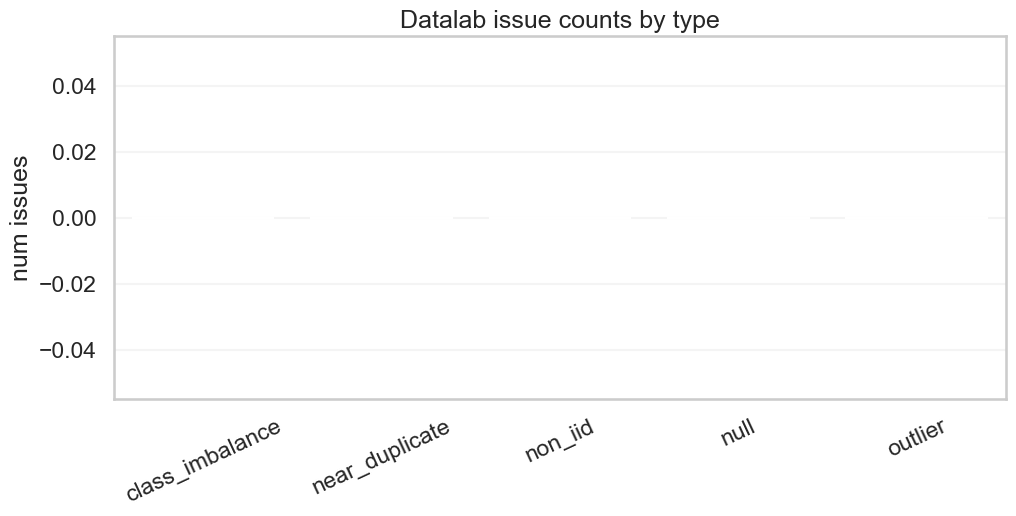

Top examples for label


KeyError: 'label_score'

In [ ]:
import io
from contextlib import redirect_stdout
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cleanlab.datalab.datalab import Datalab

sns.set_theme(style="whitegrid", context="talk")

datalab_confidence_x3_cache_path = cache_file("datalab_confidence_x3.pkl")


def _confidence_x3_pred_probs(bundle: dict[str, Any]) -> np.ndarray:
    run_probs: list[np.ndarray] = []
    for run in bundle["runs"]:
        rows = []
        for output in run:
            row = np.full(len(ALLOWED_LABELS), 1.0 / len(ALLOWED_LABELS), dtype=float)
            label = output.get("label")
            confidence = output.get("confidence")
            if label in LABEL_TO_IDX and confidence is not None:
                try:
                    confidence_value = float(confidence)
                except Exception:
                    confidence_value = None
                if confidence_value is not None and np.isfinite(confidence_value):
                    confidence_value = float(np.clip(confidence_value, 0.0, 1.0))
                    if len(ALLOWED_LABELS) > 1:
                        row[:] = (1.0 - confidence_value) / float(len(ALLOWED_LABELS) - 1)
                    row[LABEL_TO_IDX[label]] = confidence_value
            rows.append(row)
        run_probs.append(np.vstack(rows))
    return np.mean(run_probs, axis=0)


def _embed_texts(texts: list[str]) -> np.ndarray:
    vectors = [np.asarray(vector, dtype=np.float32) for vector in embedder.embed(texts)]
    # apply umap 10
    import umap
    reducer = umap.UMAP(n_components=10, random_state=SEED)
    vectors = reducer.fit_transform(vectors)
    return np.vstack(vectors) if len(vectors) > 0 else np.zeros((0, 0), dtype=np.float32)


def _top_issue_examples(issue_name: str, issues_df: pd.DataFrame, base_df: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    issue_table = issues_df.copy()
    if "row" not in issue_table.columns:
        issue_table = issue_table.reset_index().rename(columns={"index": "row"})
    merged = base_df[["row", "kind", "true_label", "is_corrupted", "text"]].merge(issue_table, on="row", how="left")
    score_col = next((col for col in issue_table.columns if col.endswith("_score")), None)
    if score_col is not None and score_col in merged.columns:
        merged = merged.sort_values(score_col, ascending=False)
    return merged.reset_index(drop=True)


def _build_datalab_bundle() -> dict[str, Any]:
    experiment_bundle = confidence_x3 if isinstance(confidence_x3, dict) else load_cache(cache_file("confidence_x3.pkl"))
    datalab_data = train_eval_df[["text", "observed_label_name"]].copy()
    datalab_data = datalab_data.rename(columns={"observed_label_name": "label"})

    pred_probs = _confidence_x3_pred_probs(experiment_bundle)
    feature_vectors = _embed_texts(datalab_data["text"].astype(str).tolist())

    lab = Datalab(datalab_data, task="classification", label_name="label", verbosity=0)
    lab.find_issues(pred_probs=pred_probs, features=feature_vectors)

    report_buffer = io.StringIO()
    with redirect_stdout(report_buffer):
        lab.report(num_examples=5, include_description=True, show_all_issues=True, show_summary_score=True)
    report_text = report_buffer.getvalue()

    issue_summary_df = lab.get_issue_summary().sort_values(["num_issues", "issue_type"], ascending=[False, True]).reset_index(drop=True)
    issues_df = lab.get_issues().reset_index().rename(columns={"index": "row"})

    issue_names_to_show = ["label", "outlier", "near_duplicate", "non_iid", "class_imbalance", "underperforming_group"]
    issue_examples = {}
    issue_counts = []
    for issue_name in issue_names_to_show:
        try:
            raw_table = lab.get_issues(issue_name).reset_index().rename(columns={"index": "row"})
            issue_examples[issue_name] = _top_issue_examples(issue_name, raw_table, train_eval_df, n=8)
            issue_flag_col = next((col for col in raw_table.columns if col.startswith("is_") and col.endswith("_issue")), None)
            issue_score_col = next((col for col in raw_table.columns if col.endswith("_score")), None)
            if issue_flag_col is not None and issue_flag_col in raw_table.columns:
                num_flagged = int(raw_table[issue_flag_col].astype(bool).sum())
            elif issue_score_col is not None and issue_score_col in raw_table.columns:
                num_flagged = int((pd.to_numeric(raw_table[issue_score_col], errors="coerce") > 0).sum())
            else:
                num_flagged = int(len(raw_table))
            issue_counts.append({
                "issue_type": issue_name,
                "num_flagged": num_flagged,
                "has_score_col": bool(issue_score_col is not None),
            })
        except Exception as exc:
            issue_examples[issue_name] = pd.DataFrame({"issue_type": [issue_name], "error": [str(exc)]})
            issue_counts.append({
                "issue_type": issue_name,
                "num_flagged": np.nan,
                "has_score_col": False,
            })

    issue_counts_df = pd.DataFrame(issue_counts)

    return {
        "experiment": "confidence_x3",
        "pred_probs": pred_probs,
        "feature_shape": tuple(feature_vectors.shape),
        "issue_summary_df": issue_summary_df,
        "issues_df": issues_df,
        "issue_counts_df": issue_counts_df,
        "issue_examples": issue_examples,
        "report_text": report_text,
        "default_issue_types": lab.list_default_issue_types(),
        "possible_issue_types": lab.list_possible_issue_types(),
    }


datalab_bundle = load_or_compute_cache(datalab_confidence_x3_cache_path, _build_datalab_bundle)

print("Cleanlab Datalab showcase")
print(f"Chosen experiment: {datalab_bundle['experiment']}")
print(f"Feature shape: {datalab_bundle['feature_shape']}")
print("Default issue types:", ", ".join(datalab_bundle["default_issue_types"]))
print("Possible issue types:", ", ".join(datalab_bundle["possible_issue_types"]))

print("Datalab report")
print(datalab_bundle["report_text"].rstrip())

print("Issue summary")
display(datalab_bundle["issue_summary_df"])

print("Issue counts by type")
display(datalab_bundle["issue_counts_df"])

fig, axis = plt.subplots(figsize=(10.5, 5.5))
issue_summary_plot = datalab_bundle["issue_summary_df"].copy()
sns.barplot(data=issue_summary_plot, x="issue_type", y="num_issues", color="#2563eb", ax=axis)
axis.set_title("Datalab issue counts by type")
axis.set_xlabel("")
axis.set_ylabel("num issues")
axis.tick_params(axis="x", rotation=25)
axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

for issue_name in ["label", "outlier", "near_duplicate", "non_iid", "class_imbalance", "underperforming_group"]:
    print(f"Top examples for {issue_name}")
    display(datalab_bundle["issue_examples"][issue_name].sort_values(f"{issue_name}_score", ascending=True))

Muller-Markert Audit: Top 10 High-Probability Mislabeled Instances


,row,text,observed_label_name,suggested_label,muller_score,is_corrupted
0,8,"Both scores were associated with death or stroke ( hazard ratio -LSB- HR -RSB- , @ ; @ % confidence interval -LSB- CI -RSB- , @-@ @ for ...",conclusions,results,0.002500,True
1,17,"Those given ATG had lower HCV recurrence ( @ vs @ % , p = @ ) .",methods,results,0.002500,True
2,13,"At the @-week visit , half ( @ % ) of the mothers who had enrolled in the study had applied for the CSG on behalf of their children , wh...",conclusions,results,0.004167,True
3,7,Streptococcus mutans is one of the most common cariogenic microorganisms .,objective,background,0.004167,True
4,14,"In @years , @ % ( CAL+BOP ) and @ % ( PD+BOP ) of healthy sites developed chronic periodontitis .",conclusions,results,0.004167,True
5,9,"Postoperative opioids were converted into oral morphine equivalents , and overall use was compared between groups .",results,methods,0.005000,True
6,16,"We conducted a prospective , randomized trial to compare the efficacy and safety of two protocols of iv @ g methylprednisolone in a tota...",objective,methods,0.005000,True
7,1,"In NAVIGATOR , patients with impaired glucose tolerance were randomly allocated to receive valsartan or placebo and nateglinide or place...",background,methods,0.005000,True
8,4,Levels of @F@ and @E@ declined exponentially thereafter with similar estimated half-lives ( @ and @ hours ) .,methods,results,0.005833,True
9,0,The primary focus was on parent-child communication and parenting .,background,objective,0.012500,True


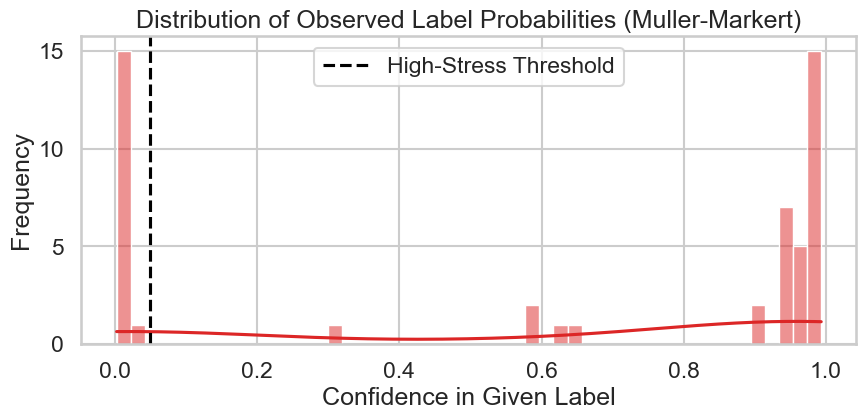

In [61]:
def analyze_muller_markert_scores(datalab_bundle: dict, df: pd.DataFrame) -> pd.DataFrame:
    """
    Implements the Muller & Markert ranking strategy using predicted probabilities.
    The core metric is the probability the model assigns to the *observed* label.
    """
    # 1. Extract pred_probs and observed labels
    pred_probs = datalab_bundle["pred_probs"]
    observed_labels = df["observed_label_name"].tolist()
    
    # 2. Map label names to indices for vectorized extraction
    label_indices = np.array([LABEL_TO_IDX[label] for label in observed_labels])
    
    # 3. Calculate Self-Confidence Score: <y_n, y_tilde_n>
    # Vectorized indexing: grab the prob at the observed label index for each row
    row_indices = np.arange(len(pred_probs))
    self_confidence_scores = pred_probs[row_indices, label_indices]
    
    # 4. Construct Audit DataFrame
    audit_df = df.copy()
    audit_df["muller_score"] = self_confidence_scores
    
    # Identify the 'Alternative' (the label the model actually preferred)
    audit_df["suggested_label"] = [ALLOWED_LABELS[i] for i in np.argmax(pred_probs, axis=1)]
    audit_df["suggested_prob"] = np.max(pred_probs, axis=1)
    
    # 5. Rank by potential error (ascending score)
    return audit_df.sort_values("muller_score", ascending=True).reset_index(drop=True)

# Execution
muller_audit = analyze_muller_markert_scores(datalab_bundle, train_eval_df)

print("Muller-Markert Audit: Top 10 High-Probability Mislabeled Instances")
display(muller_audit[["row", "text", "observed_label_name", "suggested_label", "muller_score", "is_corrupted"]].head(30))

# Visualization of the Confidence Distribution
plt.figure(figsize=(10, 4))
sns.histplot(muller_audit["muller_score"], bins=50, kde=True, color="#dc2626")
plt.axvline(x=0.05, color='black', linestyle='--', label='High-Stress Threshold')
plt.title("Distribution of Observed Label Probabilities (Muller-Markert)")
plt.xlabel("Confidence in Given Label")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### TLM

In [ ]:
# Set your API key
import os
os.environ["CLEANLAB_TLM_API_KEY"] = "<API key>"  # Get your free API key from: https://tlm.cleanlab.ai/

from cleanlab_tlm import TLM

tlm = TLM()  # See Advanced Tutorial for optional TLM configurations to get better/faster results

output = tlm.prompt("<your prompt>")

MissingApiKeyError: No API key provided. Please provide an API key using the `api_key` argument (`TLM(api_key=...)`) or by setting the `CLEANLAB_TLM_API_KEY` environment variable.